# B08 · Trace the evidence, then change the objective

Skill: implement both attention masks and a scored-only loss; explain a complete nine-fit objective ablation.

**PROVIDED** cells expose the model and trainer. **TODO** functions are live: the model calls them. **CHECK** cells give immediate feedback. **EXIT** requires your written defense as well as numerical evidence. Student blanks are intentional; use the separate solution only after attempting them.

This notebook runs offline after dependency setup. It includes frozen arrays and the pinned source packet. Fresh course training takes seconds to minutes on a CPU. No paid service is called. Full historical Table 23 inference is source-gated and full pretraining remains NOT_RUN.

[Lesson](https://avist.github.io/relational/lessons/b08-structured-objectives.html) · [LimiX-2 §§2–3](https://arxiv.org/html/2609.17488v1#S2) · [Original Table 23](https://arxiv.org/html/2509.03505v2#S7.SS3)


## Concept recap and worked trace

Support rows have known features X and target y. Query rows have observed features and an unknown target. A hidden feature is replaced by a missing embedding plus a column code. Its true value belongs to the scorer, not the encoder.

Across rows, every reader sees support keys only. Support cannot read queries either, preventing query→support→query leakage. Within a row, feature queries see feature and task states; task queries see features only. Four task slots represent one target, not four labels. An attention query/key/value denotes a retrieval role, not necessarily a dataset query row.

Equal scores give equal weights: value states 2 and 6 average to4. Letting query states 10 and 30 join changes that average to12. These are illustrative internal states, not labels. A residual connection preserves the receiving row’s own feature state.

MSE averages squared errors; RMSE is its square root. True features [2,5,9], predicted[1,7,8], first two hidden: feature loss Lx=(1+4)/2=2.5. Target truth 4,prediction 3 gives Ly=1. Combined course loss Ly+Lx=3.5. Only scored cells receive direct reconstruction gradients.

The complete course experiment holds inputs, masks, initialization, architecture, optimizer and120 steps fixed within each seed. Three objectives×three seeds = 9 fits. Exactly one feature per query is hidden. Train/test are independent streams of the same synthetic generator; no real-data transfer claim follows. Feature-only leaves the final target head untrained. Sum loss changes gradient magnitude as well as supervision.


## Model architecture · LimiX-16M

Original selected-target model:12 blocks,cell embeddings and feature reconstruction. Original model/encoder/layer source is visible in the appendix.

<img alt="Original selected-target model:12 blocks,cell embeddings and feature reconstruction. Original model/encoder/layer source is visible in the appendix." width="440" src="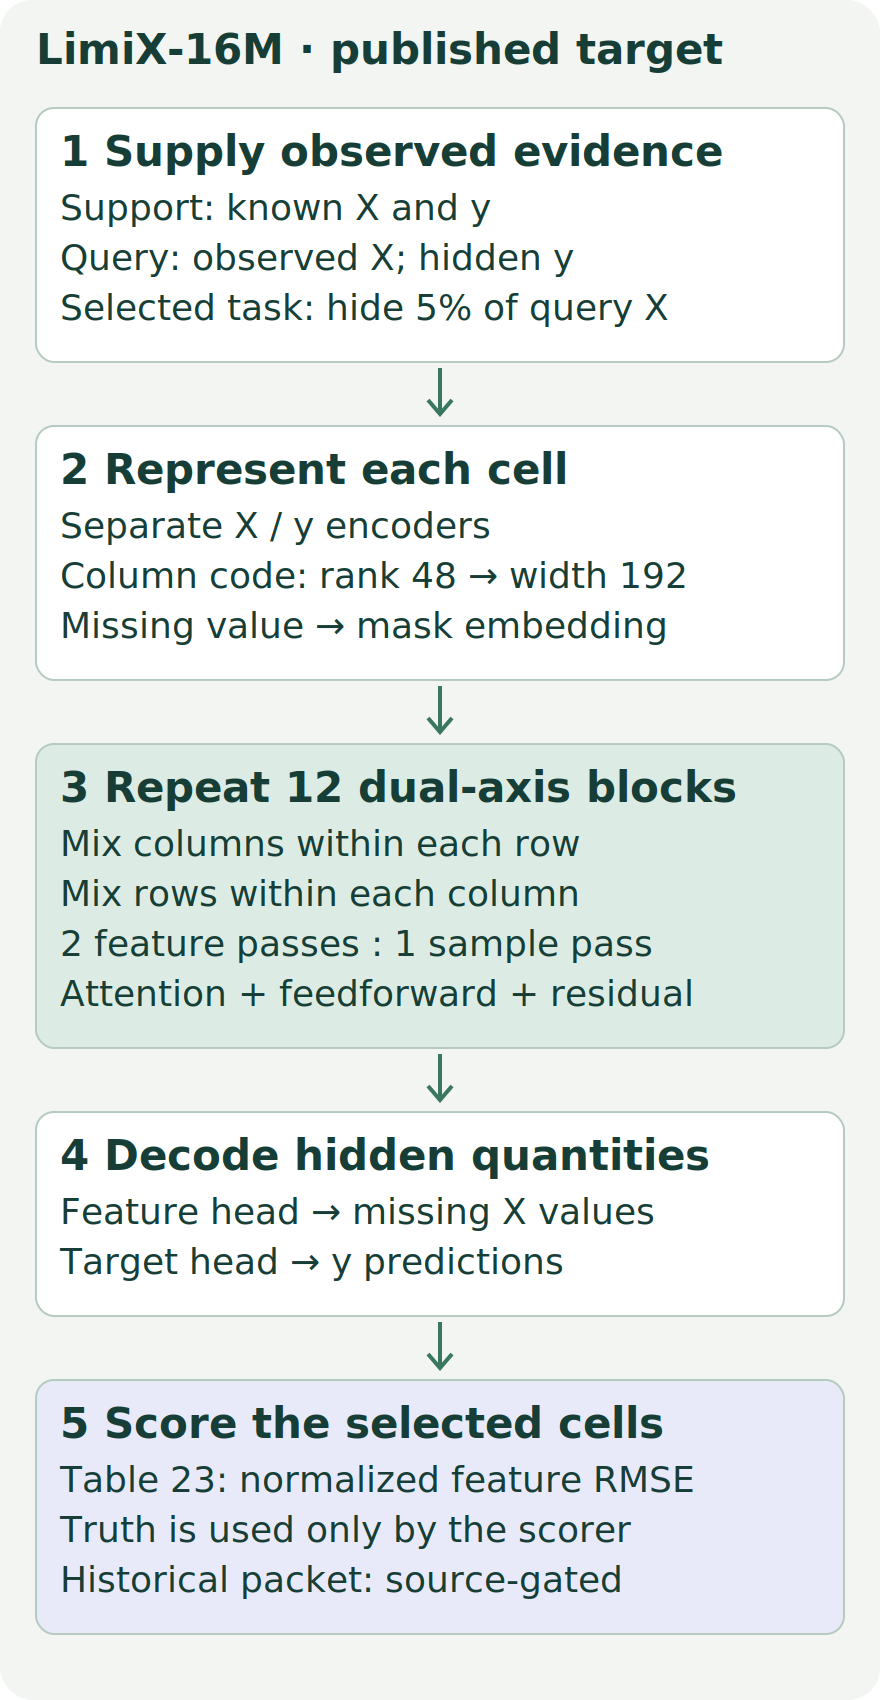">

## Model architecture · LimiX-2

24 blocks,width 256,four task slots,independent pathways. Course uses2 blocks,width 16,single-head attention,LayerNorm and scalar heads; released model uses RMSNorm,attention normalization/scaling,adapters and5000-bin regression.

<img alt="24 blocks,width 256,four task slots,independent pathways. Course uses2 blocks,width 16,single-head attention,LayerNorm and scalar heads; released model uses RMSNorm,attention normalization/scaling,adapters and5000-bin regression." width="440" src="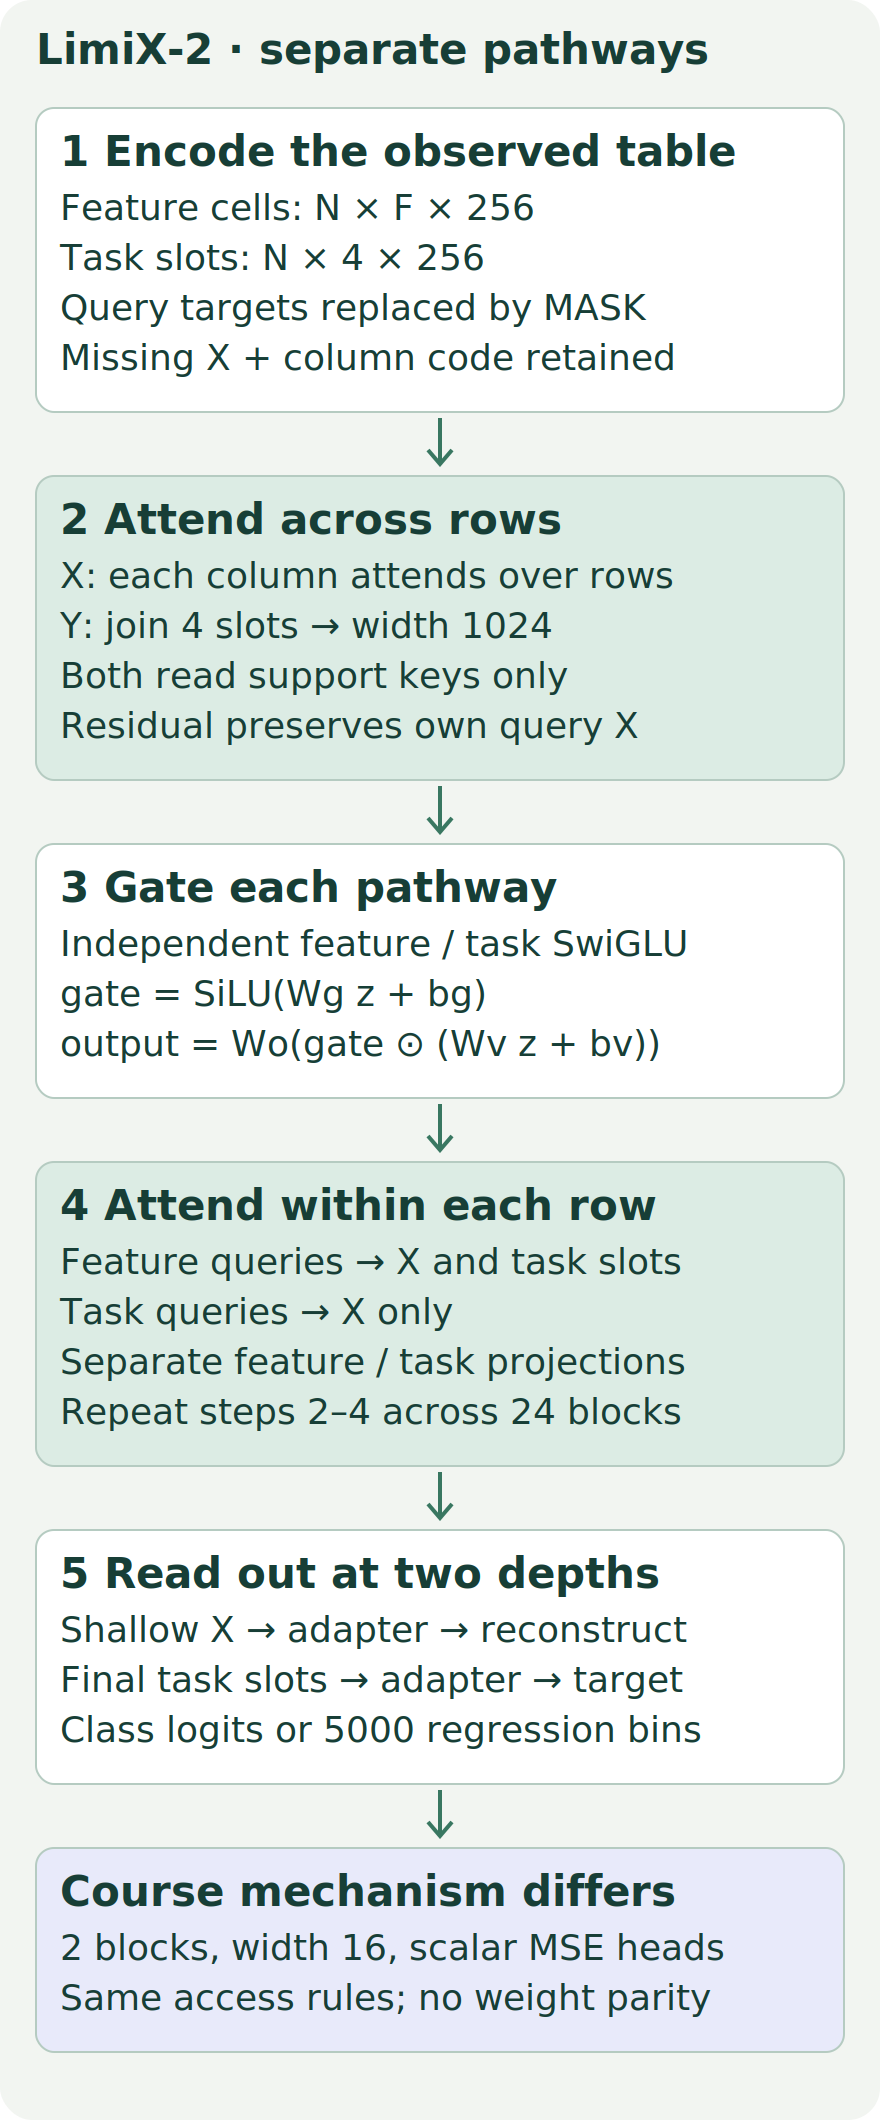">

## Two access matrices

Rows read columns; T compresses four task slots. Own query inputs survive via residuals; preprocessing must also preserve the claimed visibility.

<img alt="Rows read columns; T compresses four task slots. Own query inputs survive via residuals; preprocessing must also preserve the claimed visibility." width="440" src="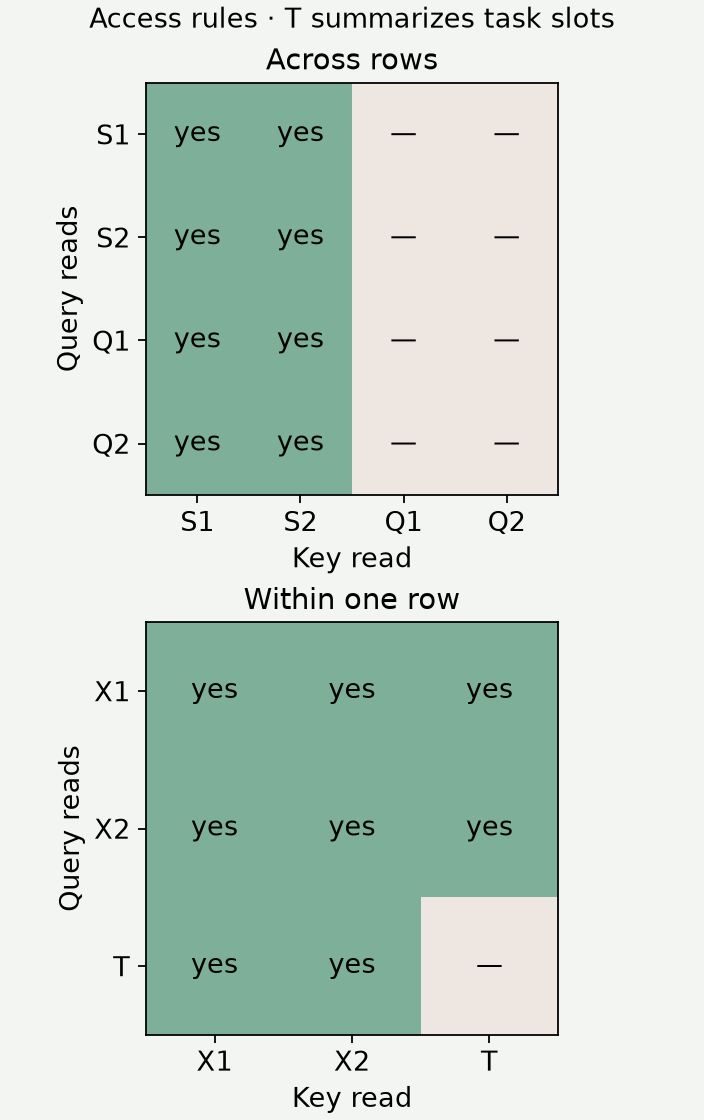">

In [ ]:
# @colab-bootstrap: install only missing packages; report drift explicitly.
import importlib.util, importlib.metadata, subprocess, sys, warnings, os
os.environ['OMP_NUM_THREADS']='1'
os.environ['OPENBLAS_NUM_THREADS']='1'
expected_versions = {'torch': '2.13.0+cpu', 'numpy': '2.5.0', 'nbformat': '5.10.4', 'nbclient': '0.11.0'}
for package in ['numpy','torch']:
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable,'-m','pip','install',package+'=='+expected_versions[package]])
    actual=importlib.metadata.version(package)
    if actual != expected_versions[package]: warnings.warn(f'{package}: {actual}; author used {expected_versions[package]}')
import numpy as np
import torch
from torch import nn
import hashlib, json, time
from pathlib import Path
print('CPU course run; no paid service. Numerical drift is reported, not hidden.')


In [ ]:
# PROVIDED: authenticate and extract the portable packet, never overwrite evidence.
import base64, io, zipfile, tempfile
encoded = '...'
raw = base64.b64decode(encoded)
assert hashlib.sha256(raw).hexdigest() == '0ff6b3e1e8c7b687ed777eab7e8b1e8a0d1325836a4d3d356865b65e382e0cb5'
packet = Path(tempfile.mkdtemp(prefix='b08-packet-'))
with zipfile.ZipFile(io.BytesIO(raw)) as archive:
    for item in archive.infolist():
        destination=(packet/item.filename).resolve()
        assert destination.is_relative_to(packet.resolve()), 'Archive traversal'
        destination.parent.mkdir(parents=True,exist_ok=True)
        destination.write_bytes(archive.read(item))
protocol=json.loads((packet/'evidence/b08/course-protocol.json').read_text())
for name,digest in protocol['data_files'].items():
    assert hashlib.sha256((packet/name).read_bytes()).hexdigest()==digest
print('Frozen inputs authenticated; originals remain immutable.')


## TODO · sample_visibility

**Goal.** Build a Boolean matrix restricting every reader to the nonempty support prefix. Reject invalid support sizes.

**Why.** This function controls actual information access or gradients in every training arm. Describe the desired rule first; the check is only a small example.

In [ ]:
def sample_visibility(rows, support):
    # TODO: implement the contract described above.
    raise NotImplementedError("Complete sample_visibility")

In [ ]:
# CHECK: sample_visibility
assert sample_visibility(4,2).tolist()==[[True,True,False,False]]*4
print("PASS: sample_visibility")

## TODO · feature_visibility

**Goal.** Build the within-row allowed-access matrix, including all four task slots. Do not confuse reader and source axes.

**Why.** This function controls actual information access or gradients in every training arm. Describe the desired rule first; the check is only a small example.

In [ ]:
def feature_visibility(features, slots):
    # TODO: implement the contract described above.
    raise NotImplementedError("Complete feature_visibility")

In [ ]:
# CHECK: feature_visibility
assert feature_visibility(2,2).tolist()==[[True]*4,[True]*4,[True,True,False,False],[True,True,False,False]]
print("PASS: feature_visibility")

## TODO · masked_mse

**Goal.** Average error only over scored cells. Reject empty or misaligned masks. An unscored prediction must have zero loss gradient.

**Why.** This function controls actual information access or gradients in every training arm. Describe the desired rule first; the check is only a small example.

In [ ]:
def masked_mse(prediction, truth, mask):
    # TODO: implement the contract described above.
    raise NotImplementedError("Complete masked_mse")

In [ ]:
# CHECK: masked_mse
p=torch.tensor([1.,100.,5.],requires_grad=True)
t=torch.tensor([3.,-100.,4.]);m=torch.tensor([True,False,True])
l=masked_mse(p,t,m);assert l.item()==2.5
l.backward();assert p.grad.tolist()==[-2.,0.,1.]
print("PASS: masked_mse")

## PROVIDED · Attention and gated transformation

Scaled dot-product attention computes softmax(QKᵀ/√d)V. Disallowed logits become−∞ before softmax. A learned gate multiplies the value transformation.

In [ ]:
class Attention(nn.Module):
    """Single-head transparent attention: softmax(QK^T/sqrt(d))V."""
    def __init__(self,d):
        super().__init__();self.q=nn.Linear(d,d);self.k=nn.Linear(d,d);self.v=nn.Linear(d,d);self.out=nn.Linear(d,d)
    def forward(self,q,kv,allowed):
        scores=self.q(q)@self.k(kv).transpose(-1,-2)/(q.shape[-1]**.5)
        weights=scores.masked_fill(~allowed.to(q.device),float('-inf')).softmax(-1)
        return self.out(weights@self.v(kv))

class SwiGLU(nn.Module):
    def __init__(self,d):
        super().__init__();self.a=nn.Linear(d,2*d);self.b=nn.Linear(d,2*d);self.c=nn.Linear(2*d,d)
    def forward(self,x):return self.c(torch.nn.functional.silu(self.a(x))*self.b(x))

## PROVIDED · One dual-axis block

Sample-axis maps are separate for X and concatenated task slots. Independent SwiGLU precedes asymmetric within-row attention. The two feature-axis updates use the same pre-update state.

In [ ]:
class DualAxis(nn.Module):
    """Separate sample-axis maps; concatenate K task slots across rows.
    Then independent feature/task SwiGLU and asymmetric within-row attention.
    """
    def __init__(self,d,k):
        super().__init__();self.d=d;self.k=k
        self.sx=Attention(d);self.sy=Attention(k*d);self.fx=Attention(d);self.fy=Attention(d)
        self.nx=nn.LayerNorm(d);self.ny=nn.LayerNorm(k*d);self.nf=nn.LayerNorm(d)
        self.gx=SwiGLU(d);self.gy=SwiGLU(k*d)
    def forward(self,x,t,support):
        b,n,f,d=x.shape;allowed=sample_visibility(n,support)
        xx=self.nx(x).transpose(1,2)
        x=x+self.sx(xx,xx,allowed).transpose(1,2)
        tt=t.reshape(b,n,self.k*d);norm=self.ny(tt)
        tt=tt+self.sy(norm,norm,allowed)
        x=x+self.gx(self.nx(x));tt=tt+self.gy(self.ny(tt));t=tt.reshape(b,n,self.k,d)
        tokens=self.nf(torch.cat([x,t],dim=2));access=feature_visibility(f,self.k)
        # Simultaneous updates: both use the same pre-feature-attention state.
        nx=x+self.fx(tokens[:,:,:f],tokens,access[:f])
        nt=t+self.fy(tokens[:,:,f:],tokens,access[f:])
        return nx,nt

## PROVIDED · Complete course forward pass

Replace hidden values before encoding. Add rank4 column codes. Two blocks route information; block1 emits feature predictions and block2 emits target predictions. This is a declared course architecture, not released-weight parity.

In [ ]:
class CourseModel(nn.Module):
    def __init__(self,d=16,k=4,features=4):
        super().__init__();self.d=d;self.k=k
        self.x_encoder=nn.Sequential(nn.Linear(1,d),nn.GELU(),nn.Linear(d,d))
        self.y_encoder=nn.Linear(1,k*d)
        self.missing=nn.Parameter(torch.randn(d)*.02);self.query_mask=nn.Parameter(torch.randn(k,d)*.02)
        self.codes=nn.Parameter(torch.randn(features,4)*.02);self.code_map=nn.Linear(4,d,bias=False)
        self.blocks=nn.ModuleList([DualAxis(d,k) for _ in range(2)])
        self.x_head=nn.Linear(d,1);self.y_head=nn.Linear(k*d,1)
    def forward(self,x,y,hidden,support):
        if x.ndim!=3 or y.shape!=x.shape[:2] or hidden.shape!=x.shape:raise ValueError('Input shape mismatch')
        b,n,f=x.shape
        safe_x=x.masked_fill(hidden,0)
        xx=torch.where(hidden[...,None],self.missing,self.x_encoder(safe_x[...,None]))+self.code_map(self.codes)[None,None]
        observed=torch.arange(n,device=x.device)<support
        safe_y=torch.where(observed,y,torch.zeros_like(y))
        tt=self.y_encoder(safe_y[...,None]).reshape(b,n,self.k,self.d)
        tt=torch.where(observed[None,:,None,None],tt,self.query_mask)
        for depth,block in enumerate(self.blocks):
            xx,tt=block(xx,tt,support)
            if depth==0: reconstruction=self.x_head(xx).squeeze(-1)
        return self.y_head(tt.flatten(-2)).squeeze(-1),reconstruction

## PROVIDED · Episodic generator and identity

A latent z generates correlated features; each episode draws target coefficients. Independent seed ranges separate train and test. Fixed feature masks are shared across objectives.

In [ ]:
def make_episodes(seed,count,batch=4,rows=32,support=24):
    """Independent episodes: latent z -> correlated features -> noisy target.
    Distinct train/eval RNGs, same generator family. No distribution-shift claim.
    Mask exactly one of four feature cells per query; never mask support.
    """
    rng=np.random.default_rng(seed)
    z=rng.normal(size=(count,batch,rows));e=rng.normal(size=(count,batch,rows,4))
    x=np.stack([z+.15*e[...,0],.8*z+.3*e[...,1],-.6*z+.4*e[...,2],e[...,3]],axis=-1).astype('float32')
    w=rng.normal(size=(count,batch,1,4)).astype('float32')/2
    y=((x*w).sum(-1)+.25*x[...,0]*x[...,1]+.1*rng.normal(size=z.shape)).astype('float32')
    hidden=np.zeros_like(x,dtype=bool)
    # One column per query chosen independently; 25% missingness in course only.
    columns=rng.integers(0,4,size=(count,batch,rows-support))
    for a in range(count):
        for b in range(batch):hidden[a,b,np.arange(support,rows),columns[a,b]]=True
    return dict(x=x,y=y,hidden=hidden)

def state_hash(model):
    h=hashlib.sha256()
    for name,t in model.state_dict().items():h.update(name.encode());h.update(t.detach().cpu().numpy().tobytes())
    return h.hexdigest()

## PROVIDED · Complete course training and inference

Each arm resets the model seed and uses AdamW for120 steps. Only the objective changes. Every test episode is evaluated; no checkpoint selection occurs.

In [ ]:
def train_arm(train,test,seed,objective,steps=120,support=24):
    """Complete fixed-step trainer; no validation selection or outcome-based retry."""
    if objective not in ['target','feature','combined']:raise ValueError('Unknown objective')
    torch.manual_seed(seed);torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
    model=CourseModel();initial=state_hash(model)
    optimizer=torch.optim.AdamW(model.parameters(),lr=.001,weight_decay=.01)
    curve=[];start=time.monotonic()
    for step in range(steps):
        x=torch.from_numpy(train['x'][step]);y=torch.from_numpy(train['y'][step]);hidden=torch.from_numpy(train['hidden'][step])
        p,r=model(x,y,hidden,support);target_mask=torch.zeros_like(y,dtype=torch.bool);target_mask[:,support:]=True
        ly=masked_mse(p,y,target_mask);lx=masked_mse(r,x,hidden)
        loss=ly if objective=='target' else lx if objective=='feature' else ly+lx
        optimizer.zero_grad();loss.backward();optimizer.step()
        if step%20==0 or step==steps-1:curve.append(dict(step=step+1,target=float(ly.detach()),feature=float(lx.detach())))
    model.eval();yp=[];xp=[]
    with torch.no_grad():
        for j in range(len(test['x'])):
            a,b=model(torch.from_numpy(test['x'][j]),torch.from_numpy(test['y'][j]),torch.from_numpy(test['hidden'][j]),support)
            yp.append(a.numpy());xp.append(b.numpy())
    return dict(y_pred=np.stack(yp),x_pred=np.stack(xp)),dict(seed=seed,objective=objective,initial_sha256=initial,final_sha256=state_hash(model),curve=curve,seconds=time.monotonic()-start,parameters=sum(p.numel() for p in model.parameters()))

## CHECK · try to leak truth or couple queries

Corrupt masked features and hidden query labels; predictions must not change. Then alter another query’s features. Finally perturb support labels: the target prediction should be allowed to change. These interventions verify an information contract.

In [ ]:
import torch, unittest

class Visibility(unittest.TestCase):
 def test_hidden_truth_and_query_batch(self):
  torch.manual_seed(8);m=CourseModel().eval();x=torch.randn(1,6,4);y=torch.randn(1,6);h=torch.zeros_like(x,dtype=torch.bool);h[:,3:,1]=True
  a,b=m(x,y,h,3)
  xx=x.clone();xx[h]=9999;yy=y.clone();yy[:,3:]=-9999
  aa,bb=m(xx,yy,h,3)
  torch.testing.assert_close(a,aa,rtol=0,atol=0);torch.testing.assert_close(b,bb,rtol=0,atol=0)
  c,d=m(x[:,:4],y[:,:4],h[:,:4],3)
  torch.testing.assert_close(a[:,:4],c,rtol=1e-5,atol=1e-6);torch.testing.assert_close(b[:,:4],d,rtol=1e-5,atol=1e-6)
  xx=x.clone();xx[:,4:]=1000;cc,dd=m(xx,y,h,3)
  torch.testing.assert_close(a[:,:4],cc[:,:4],rtol=0,atol=0)
  yy=y.clone();yy[:,:3]+=5;ee,_=m(x,yy,h,3)
  self.assertGreater((a[:,3:]-ee[:,3:]).abs().max().item(),1e-6)


result=unittest.TextTestRunner().run(unittest.defaultTestLoader.loadTestsFromTestCase(Visibility))
assert result.wasSuccessful()

## Predict, then run all nine arms

Write your prediction about combined-minus-target target MSE before running. Keep all seeds even if one looks poor. The output compares fresh arrays with saved author arrays; any drift is surfaced.

In [ ]:
prediction_before_run = ""  # Write a prediction; this is learner work.
print('Prediction recorded' if prediction_before_run.strip() else 'PENDING prediction explanation')
records=[];fresh_metrics=[]
fresh_dir=Path(tempfile.mkdtemp(prefix='b08-fresh-'))
for seed in protocol['seeds']:
    train=dict(np.load(packet/f'data/b08/train-{seed}.npz'))
    test=dict(np.load(packet/f'data/b08/test-{seed}.npz'))
    for objective in protocol['objectives']:
        arrays,record=train_arm(train,test,seed,objective)
        reference=np.load(packet/f'evidence/b08/runs/{objective}-{seed}.npz')
        for key,value in arrays.items():
            np.testing.assert_allclose(value,reference[key],rtol=0,atol=0,err_msg='Fresh prediction drift')
        yerror=arrays['y_pred'][:,:,24:].astype('float64')-test['y'][:,:,24:]
        xerror=arrays['x_pred'][test['hidden']].astype('float64')-test['x'][test['hidden']]
        fresh_metrics.append(dict(seed=seed,objective=objective,target_mse=float(np.mean(yerror**2)),feature_mse=float(np.mean(xerror**2))))
        np.savez_compressed(fresh_dir/f'{objective}-{seed}.npz',**arrays)
        records.append(record)
        print(seed,objective,'fresh predictions match exactly')
for seed in range(3):
    assert len({r['initial_sha256'] for r in records if r['seed']==seed})==1
from IPython.display import display,HTML
table='<table><tr><th>Seed</th><th>Objective</th><th>Target MSE</th><th>Feature MSE</th></tr>'
for row in fresh_metrics:
    table+=f"<tr><td>{row['seed']}</td><td>{row['objective']}</td><td>{row['target_mse']:.4f}</td><td>{row['feature_mse']:.4f}</td></tr>"
display(HTML(table+'</table>'))


## Author-reference evidence · interpret after your run

| Objective | Target MSE ↓ | Feature MSE ↓ |
|---|---:|---:|
| target | 0.6704 ± 0.2326 | 0.7917 ± 0.0886 |
| feature | 1.2523 ± 0.3373 | 0.7224 ± 0.1333 |
| combined | 0.7536 ± 0.2303 | 0.7812 ± 0.0856 |


Values are **mean ± sample SD across three seeds**, not confidence intervals. Each seed includes 128 target predictions and 128 scored feature cells per arm. All 9 arms  / 1,152 target predictions  / 1,152 scored feature predictions passed independent scoring. The same inputs and initial weights are paired across arms.

Combined-minus-target-only target MSE is **+0.00384, −0.04761, +0.29332** for seeds 0, 1, 2. Only seed 1 improves. Mean target MSE rises from 0.6704 to 0.7536. Reconstruction-only has the lowest mean feature MSE, but its target head is untrained.

The support-mean baseline has target MSE**0.8537** and feature MSE**0.7974** averaged across the same three seeds. Combined reconstruction does not beat that feature baseline in every seed. This brief training recipe provides mixed evidence, not a general benefit for joint modeling. A seed bundles initialization and episode streams; its SD includes both. Three seeds from one synthetic family do not justify real-dataset ranks or a model-family ranking. No post-result retuning was performed.


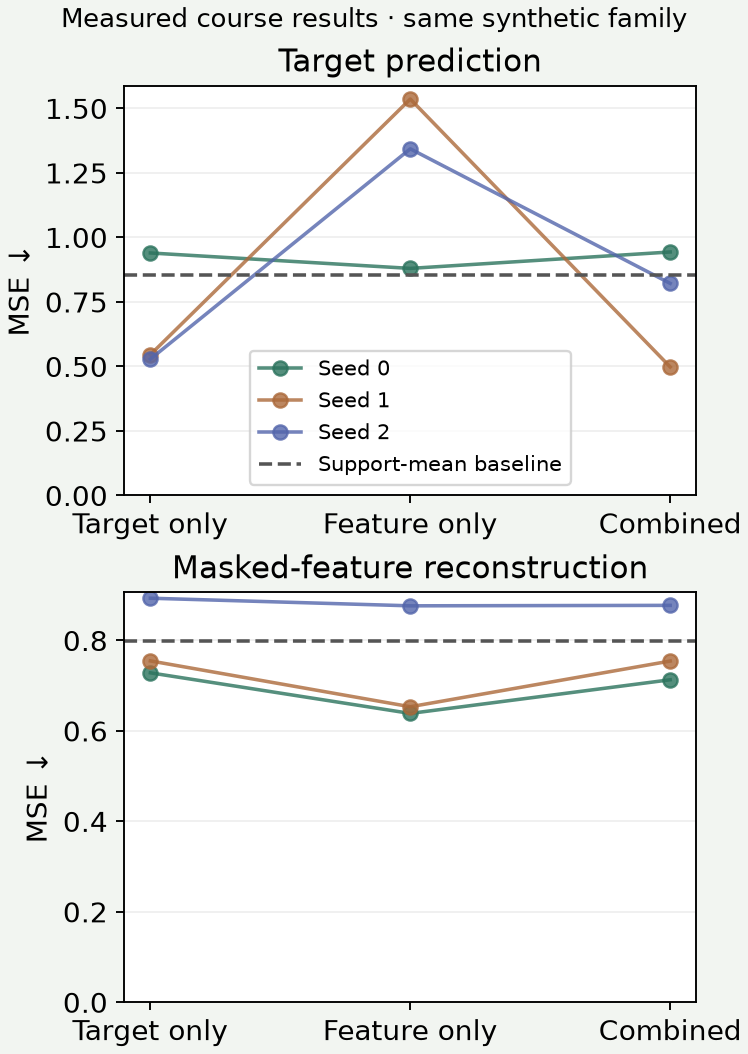

## NEXT STEP · selected paper result

The target is original Table 23 Analcatdata BroadwayMult,normalized RMSE 0.194 at 5% masking. Both archived demos use breast-cancer data and 30% masking. Original row/mask/scaler/repetition/checkpoint identities are not authenticated. Current BCCO BroadwayMult train/test candidate bytes are pinned, but the 5% mask and their historical Table 23 identity are not authenticated. Current full released inference is provided but NOT_RUN; historical dispatch fails closed. Read `b08-reproduction.md` in the packet for the authenticated numeric-packet interface. Course heads and masks do not substitute for the released model. Full pretraining trainer/data are unavailable in this packet.

In [ ]:
# PROVIDED: authenticate source and show the real historical blocker.
sys.path.insert(0,str(packet))
from _reproduce_b08 import source_audit
source_status=source_audit()
print(source_status['status'])
for blocker in source_status['blockers']:print('•',blocker)
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    result=subprocess.run([sys.executable,str(packet/'_reproduce_b08.py'),'--lane','paper'])
    assert result.returncode==2, 'Historical gate unexpectedly bypassed'


## EXIT · numerical output plus written defense

Explain both attention axes, why feature-only has an untrained target head, all three paired target effects, and the missing evidence for Table 23. Numerical checks alone do not mark your learning complete. Paste your explanation to the agent for feedback.

In [ ]:
written_defense = ""  # Learner writes this; author leaves it blank.
submission=dict(status='PENDING_WRITTEN_DEFENSE',course_arms=len(records),source=source_status['status'],written_defense=written_defense)
Path('b08-submission.json').write_text(json.dumps(submission,indent=2))
report=dict(fresh=True,metrics=fresh_metrics,source=source_status['status'],all_prediction_arrays='EXACT',learner=submission['status'])
Path('b08-report.json').write_text(json.dumps(report,indent=2))
print(submission)


## Appendix · full original release core, readable without imports

The following archived source is displayed for inspection, not executed as course code. It comes from publication-era commitc6f677f8e884e86b7638e0cda978bbccf7b45e1a. The complete historical snapshot and current release are also in the authenticated packet. Map embeddings→encoder; attention/residuals→layer; backbone/heads→transformer; preprocessing/inference→predictor and inference_method. Original pretraining is not supplied or claimed. The selected inference operator uses the separately pinned current release.

### Archived source · model/encoders.py

SHA256 `293f17b5241a94381a3a33ec3e999031765203ece7ebceb4735bad395ed85fbc`. Author release code; dependencies and licenses are in the packet.

```python
import torch
import torch.nn as nn
from model.layer import EncoderBaseLayer, MLP
from typing import Any,Literal
from torch.nn.init import orthogonal_
import numpy as np

```

```python
def calc_mean(x:torch.Tensor, dim:int):
    num = torch.sum(~torch.isnan(x), dim=dim).clip(min=1.0)
    return torch.nansum(x, dim=dim) / num, num

```

```python
def calc_std(x:torch.Tensor, dim:int, mean_v:torch.Tensor|None = None, value_num:torch.Tensor|None=None ):
    if mean_v is None or value_num is None:
        mean_v, value_num = calc_mean(x, dim)
    mean_broadcast = torch.repeat_interleave(mean_v.unsqueeze(dim), x.shape[dim], dim=dim,)
    return torch.sqrt(torch.nansum(torch.square(mean_broadcast - x), dim=dim) / (value_num - 1))

```

```python
def drop_outliers(
                    x:torch.Tensor, 
                    std_sigma:float=4,
                    eval_pos:int=-1,
                    lower:torch.Tensor|None = None,
                    upper:torch.Tensor|None = None,
                    dim:int=1
                    ):
        assert len(x.shape)==3, "x.shape must be B,S,F"

        if lower is None:
            data = x[:,:eval_pos].clone()
            data_mean, value_num = calc_mean(data, dim=dim)
            data_std = calc_std(data, dim=dim, mean_v=data_mean, value_num=value_num)
            cut_off = data_std * std_sigma
            lower, upper = data_mean - cut_off, data_mean + cut_off
            
            data[torch.logical_or(data > upper, data < lower)] = np.nan
            data_mean, value_num = calc_mean(data, dim=dim)
            data_std = calc_std(data, dim=dim, mean_v=data_mean, value_num=value_num)
            cut_off = data_std * std_sigma
            lower, upper = data_mean - cut_off, data_mean + cut_off
        
        x = torch.maximum(-torch.log(1 + torch.abs(x)) + lower, x)
        x = torch.minimum(torch.log(1 + torch.abs(x)) + upper, x)
        
        return x, lower, upper
    
```

```python
def normalize_mean0_std1(
                        x:torch.Tensor, 
                        eval_pos:int=-1,
                        clip:bool=True,
                        dim:int=1,
                        mean: torch.Tensor | None = None,
                        std: torch.Tensor | None = None
                        ):
    if mean is None:
        mean, value_num = calc_mean(x[:,:eval_pos], dim=dim)
        std = calc_std(x[:,:eval_pos], dim=dim, mean_v=mean, value_num=value_num) + 1e-20
        
        if x.shape[1] == 1 or eval_pos == 1:
            std[:] = 1.0
    x = (x - mean.unsqueeze(1).expand_as(x)) / std.unsqueeze(1).expand_as(x)
    if clip:
        x = torch.clip(x, min=-100, max=100)
    return x, mean, std
    

```

```python
class LinearEncoder(nn.Module):
    """linear input encoder"""
    def __init__(
                self,
                num_features: int,
                emsize: int,
                nan_to_zero: bool = False,
                bias: bool = True,
                in_keys:list[str]=['data'],
                out_key:str='data',
    ):
        """Initialize the LinearEncoder.

        Args:
            num_features: The number of input features.
            emsize: The embedding size, i.e. the number of output features.
            nan_to_zero: Whether to replace NaN values in the input by zero. Defaults to False.
            bias: Whether to use a bias term in the linear layer. Defaults to True.
        """
        super().__init__()
        self.layer = nn.Linear(num_features, emsize, bias=bias)
        self.nan_to_zero = nan_to_zero
        self.in_keys = in_keys
        self.out_key = out_key
        
    def forward(self, input:dict[str, torch.Tensor|int])->dict[str, torch.Tensor]:
        assert 'data' in input and 'nan_encoding' in input
        x = [input[key] for key in self.in_keys] 
        x = torch.cat(x, dim=-1) # type: ignore
        if self.nan_to_zero:
            x = torch.nan_to_num(x, nan=0.0)
            
        input[self.out_key] = self.layer(x)
        return input

```

```python
class MLPEncoder(nn.Module):
    """MLP input encoder"""
    def __init__(
                self,
                num_features: int,
                emsize: int,
                nan_to_zero: bool = False,
                bias: bool = True,
                in_keys: list[str] = ['data'],
                out_key: str = 'data',
    ):
        """Initialize the MLPEncoder.

        Args:
            num_features: The number of input features.
            emsize: The embedding size, i.e. the number of output features.
            nan_to_zero: Whether to replace NaN values in the input by zero. Defaults to False.
            bias: Whether to use a bias term in the linear layer. Defaults to True.
        """
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(num_features, emsize * 2, bias=bias),
            nn.LayerNorm(emsize * 2),
            nn.GELU(),
            nn.Linear(emsize * 2, emsize, bias=bias),
            nn.LayerNorm(emsize),
            nn.GELU()
        )
        self.nan_to_zero = nan_to_zero
        self.in_keys = in_keys
        self.out_key = out_key
        
    def forward(self, input:dict[str, torch.Tensor|int])->dict[str, torch.Tensor]:
        assert 'data' in input and 'nan_encoding' in input
        x = [input[key] for key in self.in_keys]
        x = torch.cat(x, dim=-1) # type: ignore
        if self.nan_to_zero:
            x = torch.nan_to_num(x, nan=0.0)
        input[self.out_key] = x
        return input

```

```python
class MaskEmbEncoder(nn.Module):
    """
    For masked features, use the mask vector to obtain their representations; 
    for numerical features, use a nonlinear network to obtain their representations
    """
    def __init__(
                self,
                num_features: int,
                emsize: int,
                mask_embedding_size: int,
                nan_to_zero: bool = False,
                bias: bool = True,
                in_keys: list[str] = ['data'],
                out_key: str = 'data',
    ):
        """Initialize the MaskEmbEncoder.

        Args:
            num_features: The number of input features.
            emsize: The embedding size, i.e. the number of output features.
            nan_to_zero: Whether to replace NaN values in the input by zero. Defaults to False.
            bias: Whether to use a bias term in the linear layer. Defaults to True.
        """
        super().__init__()
        self.embedding_dim = emsize
        self.mask_embedding_size = mask_embedding_size
        self.in_keys = in_keys
        self.out_key = out_key

        # All masked positions use the same vector
        self.mask_embedding = nn.Parameter(torch.randn(self.mask_embedding_size))

        # MLP for numerical features: input is 1, output is embedding_dim
        self.numeric_mlp = nn.Sequential(
            nn.Linear(1, self.embedding_dim // 2, bias=bias),
            nn.LayerNorm(self.embedding_dim // 2),
            nn.ReLU(),
            nn.Linear(self.embedding_dim // 2, self.embedding_dim, bias=bias),
            nn.LayerNorm(self.embedding_dim),
            nn.ReLU()
        )

        # Merging layer: maps the concatenated feature vectors back to embedding_dim.
        self.fusion_network = nn.Sequential(
            nn.Linear(num_features * self.embedding_dim, self.embedding_dim, bias=bias),
            nn.LayerNorm(self.embedding_dim),
            nn.ReLU(),
            nn.Linear(self.embedding_dim, self.embedding_dim, bias=bias),
            nn.LayerNorm(self.embedding_dim)
        )
        self.nan_to_zero = nan_to_zero
    
    def forward(self, input:dict[str, torch.Tensor|int])->dict[str, torch.Tensor]:
        assert 'data' in input and 'nan_encoding' in input
        x = [input[key] for key in self.in_keys]
        x = torch.cat(x, dim=-1) # type: ignore
        batch_size, seq_len, group, feature_num = x.shape
        x_flat = x.view(-1, feature_num)
        is_mask = torch.isnan(x_flat)
        feature_embeddings = []   
        for i in range(feature_num):
            feat_vals = x_flat[:, i].unsqueeze(-1)
            feat_is_mask = is_mask[:, i].unsqueeze(-1)

            # Processing numerical features
            numeric_input = torch.where(~feat_is_mask, feat_vals, torch.zeros_like(feat_vals))
            numeric_emb = self.numeric_mlp(numeric_input)

            # Construct mask embedding
            mask_emb = self.mask_embedding.expand(numeric_emb.shape[0], -1)
            
            # Merge the embedding results of masked features and numerical features
            combined_emb = torch.where(feat_is_mask.expand_as(numeric_emb), mask_emb, numeric_emb)
            feature_embeddings.append(combined_emb)
        concat_vector = torch.cat(feature_embeddings, dim=-1)

        sample_representation = self.fusion_network(concat_vector)
        output = sample_representation.view(batch_size, seq_len, group, -1)
        
        
        input[self.out_key] = output
        return input

```

```python
class NanEncoder(nn.Module):
    """Encoder stage that deals with NaN and infinite values in the input"""
    def __init__(
        self,
        nan_value: float = -2.0,
        inf_value: float = 2.0,
        neg_info_value: float = 4.0,
        in_keys:list[str]=['data'],
        out_key:str='nan_encoding'
    ):
        """Initialize the NanEncoder.

        Args:
            keep_nans: Flag to maintain NaN values as individual indicators. 
        """
        super().__init__()
        self.nan_value = nan_value
        self.inf_value = inf_value
        self.neg_info_value = neg_info_value
        self.in_keys = in_keys
        self.out_key = out_key
        
    def forward(self, input:dict[str, torch.Tensor|int])->dict[str, torch.Tensor]:
        x:torch.Tensor = input[self.in_keys[0]] # type: ignore
        eval_pos = input['eval_pos']
        
        mean_value, _ = calc_mean(x[:,:eval_pos,:], dim=1)
        
        nans_indicator = torch.zeros_like(x, dtype=x.dtype)
        nans_indicator[torch.isnan(x)] = self.nan_value
        pos_inf_mask = torch.isinf(x) & (torch.sign(x) == 1)
        nans_indicator[pos_inf_mask] = self.inf_value
        neg_inf_mask = torch.isinf(x) & (torch.sign(x) == -1)
        nans_indicator[neg_inf_mask] = self.neg_info_value
        nan_mask = torch.logical_or(torch.isnan(x), torch.isinf(x))
        # avoid inplace operations
        x = x.clone()
        x[nan_mask] = mean_value.unsqueeze(1).expand_as(x)[nan_mask]
        
        input[self.in_keys[0]] = x
        input[self.out_key ] = nans_indicator
        return input
        
    
```

```python
class ValidFeatureEncoder(nn.Module):
    """Valid feature encoder"""
    def __init__(
        self,
        num_features: int,
        nan_normalize: bool=True,
        sqrt_normalize: bool=True,
        in_keys:list[str]=['data'],
        out_key:str='data'
    ):
        """Initialize the ValidFeatureEncoder.

        Args:
            num_features: The target number of features to transform the input into.
            nan_normalize: Indicates whether to normalize based on the number of features actually used.
            sqrt_normalize: Legacy option to normalize using the square root rather than the count of used features.
        """
        super().__init__()
        self.num_features = num_features
        self.nan_normalize = nan_normalize
        self.sqrt_normalize = sqrt_normalize
        self.in_keys = in_keys
        self.out_key = out_key
        self.valid_feature_num = None
    
    def forward(self, input:dict[str, torch.Tensor|int])->dict[str, torch.Tensor]:
        x:torch.Tensor = input[self.in_keys[0]]  # type: ignore
        valid_feature = ~torch.all(x == x[:, 0:1, :], dim=1)
        self.valid_feature_num = torch.clip(valid_feature.sum(-1).unsqueeze(-1),min=1)

        if self.nan_normalize:
            if self.sqrt_normalize:
                x = x * torch.sqrt(self.num_features / self.valid_feature_num).unsqueeze(1).expand_as(x)
            else:
                x = x * (self.num_features / self.valid_feature_num)
        
        zeros = torch.zeros(
            *x.shape[:-1],
            self.num_features - x.shape[-1],
            device=x.device,
            dtype=x.dtype,
        )
        x = torch.cat([x, zeros], -1)
        
        input[self.out_key] = x
        return input
    

```

```python
class EmbYEncoderStep(nn.Module):
    """A simple linear input encoder step."""

    def __init__(
        self,
        *,
        emsize: int,
        n_classes: int = 10,
        in_keys: list[str] = ['data'],
        out_key: str = 'data',
    ):
        """Initialize the EmbYEncoderStep.

        Args:
            emsize: The embedding size, i.e. the number of output features.
            n_classes: Number of classes
        """
        super().__init__()
        
        # Ensure the embedding dimension is large enough to support orthogonal initialization.
        assert emsize > n_classes + 1, (f"emsize ({emsize}) must be >= n_classes+1 ({n_classes+1}) for orthogonal initialization")

        # Generate an orthogonal matrix of size (n_classes + 1) × emsize
        ortho_matrix = torch.empty(n_classes + 1, emsize)
        orthogonal_(ortho_matrix)  # Initialize in-place as an orthogonal matrix

        # Decompose the matrix: the first n_classes rows are used for y_embedding, and the last row is used for y_mask.
        y_embed_weights = ortho_matrix[:n_classes, :]  # Shape (n_classes, emsize)
        y_mask_weight = ortho_matrix[n_classes:n_classes+1, :]  # Shape (1, emsize)

        self.y_embedding = nn.Embedding(n_classes, emsize)
        self.y_embedding.weight.data = y_embed_weights.clone()

        self.y_mask = nn.Embedding(1, emsize)
        self.y_mask.weight.data = y_mask_weight.clone()
        self.in_keys = in_keys
        self.out_key = out_key
        if len(self.in_keys) > 1:
            print("Warning: The EmbYEncoderStepl function is only for processing Y, and in_keys must contain exactly one key.")
        
    def forward(self, input:dict[str, torch.Tensor|int])->dict[str, torch.Tensor]:
        y = input[self.in_keys[0]]
        eval_pos = input['eval_pos']
        y = y.int() # type: ignore
        y_train = y[:,:eval_pos]
        y_test = torch.zeros_like(y[:, eval_pos:], dtype=torch.int)
        y_train_emb = self.y_embedding(y_train).to(torch.float16)
        y_test_emb = self.y_mask(y_test).to(torch.float16)
        y_emb = torch.cat([y_train_emb, y_test_emb], dim=1)
        
        input[self.out_key] = y_emb
        return input

```

```python
class MulticlassTargetEncoder(nn.Module):
    """Use the target's index as the class value, with each class corresponding to an index"""
    def __init__(
        self,
        in_keys:list[str]=['data'],
        out_key:str='data'
    ):
        """Initialize the ValidFeatureEncoder.

        Args:
            in_keys: the keys of the input parameter
            out_key: the key of the output result.
        """
        super().__init__()
        self.in_keys = in_keys
        self.out_key = out_key
    
    def forward(self, input:dict[str, torch.Tensor|int])->dict[str, torch.Tensor]:
        x:torch.Tensor = input[self.in_keys[0]]  # type: ignore
        eval_pos = input['eval_pos']
        unique_xs = [
            torch.unique(x[b, :eval_pos]) for b in range(x.shape[0])
        ]
        x_ = x.clone()
        for b in range(x.shape[0]):
            x_[b, :, :] = (x[b, :, :].unsqueeze(-1) > unique_xs[b]).sum(dim=-1)
   
        input[self.out_key] = x_
        return input

```

```python
class NormalizationEncoder(nn.Module):
    """normalize encoder"""
    def __init__(
                self, 
                train_only:bool,
                normalize_x:bool,
                remove_outliers:bool,
                std_sigma:float=4.0,
                in_keys:list[str]=['data'],
                out_key:str='data'
                
    ):
        super().__init__()
        self.train_only = train_only
        self.normalize_x = normalize_x
        self.remove_outliers = remove_outliers
        self.std_sigma = std_sigma
        self.in_keys = in_keys
        self.out_key = out_key
        self.mean = None
        self.std = None

    def forward(self, input:dict[str, torch.Tensor|int])->dict[str, torch.Tensor]:
        x = input[self.in_keys[0]]
        eval_pos = input['eval_pos']
        pos = eval_pos if self.train_only else -1
        if self.remove_outliers:
            x, lower, upper = drop_outliers(x, eval_pos=pos, std_sigma=self.std_sigma)
        if self.normalize_x:
            x, self.mean, self.std = normalize_mean0_std1(x, eval_pos=pos )
        
        input[self.out_key] = x
        return input



```

```python
def get_x_encoder(
    *,
    num_features: int,
    embedding_size: int,
    mask_embedding_size: int,
    encoder_use_bias: bool,
    in_keys: list = ['data']
):
    inputs_to_merge = {}
    for in_key in in_keys:
        inputs_to_merge[in_key] = {'dim': num_features}

    encoder_steps = [
        MaskEmbEncoder(
            num_features=sum([i["dim"] for i in inputs_to_merge.values()]),
            emsize=embedding_size,
            mask_embedding_size=mask_embedding_size,
            bias=encoder_use_bias,
        ),
    ]

    return nn.Sequential(*encoder_steps,)


```

```python
def get_cls_y_encoder(
    *,
    num_inputs: int,
    embedding_size: int,
    nan_handling_y_encoder: bool,
    max_num_classes: int
) -> nn.Module:
    steps = []
    inputs_to_merge = [{"name": "data", "dim": num_inputs}]
    if nan_handling_y_encoder:
        steps += [NanEncoder(in_keys=['data'], out_key='nan_encoding')]
        inputs_to_merge += [{"name": "nan_indicators", "dim": num_inputs}]

    if max_num_classes >= 2:
        steps += [MulticlassTargetEncoder()]

    steps += [
            EmbYEncoderStep(
                emsize=embedding_size,
                n_classes=max_num_classes
        )
    ]
    return nn.Sequential(*steps)

```

```python
def get_reg_y_encoder(
    *,
    num_inputs: int,
    embedding_size: int,
    nan_handling_y_encoder: bool,
    max_num_classes: int
) -> nn.Module:
    steps = []
    inputs_to_merge = [{"name": "data", "dim": num_inputs}]
    if nan_handling_y_encoder:
        steps += [NanEncoder(in_keys=['data'], out_key='nan_encoding')]
        inputs_to_merge += [{"name": "nan_indicators", "dim": num_inputs}]

    steps += [
        LinearEncoder(
            num_features=sum([i["dim"] for i in inputs_to_merge]),  # type: ignore
            emsize=embedding_size,
            in_keys=['data', 'nan_encoding'],
            out_key='data'
        ),
    ]
    return nn.Sequential(*steps)


```

```python
def preprocesss_4_x(
    *,
    num_features: int,
    nan_handling_enabled: bool,
    normalize_on_train_only: bool,
    normalize_x: bool,
    remove_outliers: bool,
    normalize_by_used_features: bool,
    ):
    """feature preprocess"""
    inputs_to_merge = {"data": {"dim": num_features}}

    preprocess_steps = []

    # Obtain the positions of features with NaN and Inf values, and replace these features with the mean of the corresponding feature
    preprocess_steps += [NanEncoder(in_keys=['data'], out_key='nan_encoding')]   
    
    if nan_handling_enabled:
        inputs_to_merge["nan_encoding"] = {"dim": num_features}
        preprocess_steps += [
            # Zero values are added to convert the input into a fixed number of features, without normalization (variance is not constant). 
            # This transformation is applied to the nan_indicators set, which shares the same shape as x. 
            # However, since x has been imputed prior to this step, this operation is theoretically redundant.
            ValidFeatureEncoder(
                num_features=num_features,
                nan_normalize=False,
                in_keys=["nan_encoding"],
                out_key="nan_encoding"
            ),
        ]

    preprocess_steps += [
        NormalizationEncoder(
            train_only=normalize_on_train_only,
            normalize_x=normalize_x,
            remove_outliers=remove_outliers,
        ),
    ]

    preprocess_steps += [
        # Convert the input into a fixed number of features by adding zero values, with normalization applied (variance is constant).
        ValidFeatureEncoder(
            num_features=num_features,
            nan_normalize=normalize_by_used_features,
        ),
    ]

    return nn.Sequential(*preprocess_steps)
```

### Archived source · model/layer.py

SHA256 `0a2efe6f0b7c121eb30faf1b3b430c868c733227bb93311933d337343e6310f3`. Author release code; dependencies and licenses are in the packet.

```python
from typing import Callable, Literal, Optional
import functools

import torch
import torch.nn as nn
from torch.utils.checkpoint import checkpoint

try:
    from flash_attn.flash_attn_interface import flash_attn_varlen_kvpacked_func, flash_attn_varlen_qkvpacked_func

    HAVE_FLASH_ATTN = True
except (ModuleNotFoundError, ImportError):
    HAVE_FLASH_ATTN = False

from functools import partial
from typing_extensions import override

Activation = Literal['gelu']

ACTIVATION_FN: dict[str, Callable[[torch.Tensor], torch.Tensor]] = {
    'gelu': nn.GELU(), 
    'relu': nn.ReLU(),
}

```

```python
class LayerNormMixedPrecision(nn.LayerNorm):
    """
    When the embedding dimension is below 512, use half precision for computation to improve performance. 
    If the embedding dimension exceeds 512, it may cause training instability.
    """
    def forward(self, input: torch.Tensor):
        if input.dtype == torch.float16 and sum(self.normalized_shape) < 512:
            with torch.amp.autocast("cuda" if input.is_cuda else "cpu", enabled=False):
                return super().forward(input)
        else:
            return super().forward(input)

```

```python
class MLP(torch.nn.Module):
    """Multi-Layer Perceptron"""
    def __init__(self, 
                 in_features: int, 
                 hidden_size:int, 
                 out_features: int, 
                 has_bias:bool, 
                 device: torch.device | None, 
                 dtype: torch.dtype | None,  
                 activation: Activation = 'gelu', 
                 depth:int=2):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.activation = activation
        self.layers = []
       
        if depth == 1:
            self.layers.append(nn.Linear(in_features, out_features, bias=has_bias, device=device, dtype=dtype))
        else:
             # input layer
            self.layers.append(nn.Linear(in_features, hidden_size, bias=has_bias, device=device, dtype=dtype))
            self.layers.append(ACTIVATION_FN[self.activation])
            # hidden layers
            for i in range(depth - 2):
                self.layers.append(nn.Linear(hidden_size, hidden_size, bias=has_bias, device=device, dtype=dtype))
                self.layers.append(ACTIVATION_FN[self.activation])
            # output layer
            self.layers.append(nn.Linear(hidden_size, out_features, bias=has_bias, device=device, dtype=dtype))
            torch.nn.init.normal_(self.layers[-1].weight)
        self.mlp = nn.Sequential(*self.layers)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(x)

```

```python
class MultiheadAttention(torch.nn.Module):
    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        device: Optional[torch.device] = None,
        dtype: Optional[torch.dtype] = None,
        qkv_combined: bool = True,
        dropout:float=0,
        recompute:bool=False
    ):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv_combined = qkv_combined
        self.dropout = dropout
        self.recompute = recompute
        self.device = device
        self.dtype = dtype

        self.out_proj_weight = torch.nn.Parameter(torch.empty(self.num_heads, self.head_dim, self.embed_dim, device=self.device, dtype=self.dtype))
        self.qkv_proj_weight = torch.nn.Parameter(torch.empty(3, self.num_heads, self.head_dim, self.embed_dim, device=device, dtype=dtype))

        torch.nn.init.normal_(self.out_proj_weight)
        nn.init.xavier_uniform_(self.qkv_proj_weight)

        self.q_proj_weight = None
        self.kv_proj_weight = None
        
        if recompute:
            self.forward = partial(checkpoint, self.forward, use_reentrant=False)  # type: ignore
    
    def get_cu_seqlens(self, batch_size: int, seqlen: int, device: torch.device) -> torch.Tensor:
        return torch.arange(
            0,
            (batch_size + 1) * seqlen,
            step=seqlen,
            dtype=torch.int32,
            device=device,
        )
    
    def compute_attention_by_torch(self, qkv:torch.Tensor|None, q:torch.Tensor|None, kv:torch.Tensor|None, attn_mask:torch.Tensor|None) -> torch.Tensor:
        '''Since flash attention does not support attn_mask, use scaled_dot_product_attention to compute attention when attn_mask is not None'''
        if qkv is not None:
            q, k, v = qkv.unbind(dim=-3)
        elif kv is not None and q is not None:
            k,v = kv.unbind(dim=-3)
        else:
            raise ValueError("When qkv is None, q and kv cannot both be None at the same time")
        assert q is not None and k is not None and v is not None, "q, k, and v must not be None"
        
        attention_outputs = torch.nn.functional.scaled_dot_product_attention(
                q.transpose(1, 2),
                k.transpose(1, 2),
                v.transpose(1, 2),
                attn_mask=attn_mask,
                dropout_p=self.dropout,
            )
        attention_outputs = attention_outputs.transpose(1, 2)
        return attention_outputs
    
    def compute_attention_by_flashattn(self, qkv:torch.Tensor|None, q:torch.Tensor|None, kv:torch.Tensor|None) -> torch.Tensor:
        "Compute attention using flash attention"
        assert HAVE_FLASH_ATTN, "Flash attention is not supported. Please install/reinstall flash attention."
        if self.qkv_combined and qkv is not None:
            B,S = qkv.shape[:2]
            atten_out = flash_attn_varlen_qkvpacked_func( # type: ignore
                        qkv.reshape(B * S, 3, self.num_heads, self.head_dim),
                        self.get_cu_seqlens(B, S, qkv.device),
                        S,
                        dropout_p=self.dropout,
                        softmax_scale=None,
                        causal=False,
                        return_attn_probs=False,
                        deterministic=False,
                    )
        elif not self.qkv_combined and q is not None and kv is not None:
            B,S = q.shape[:2]
            kv_shape = kv.shape
            atten_out = flash_attn_varlen_kvpacked_func( # type: ignore
                    q.reshape(B * S, self.num_heads, self.head_dim),
                    kv.reshape(B * kv_shape[1], 2, self.num_heads, self.head_dim),
                    self.get_cu_seqlens(B, S, q.device),
                    self.get_cu_seqlens(B, kv_shape[1], kv.device),
                    S,
                    kv_shape[1],
                    dropout_p=self.dropout,
                    causal=False,
                    return_attn_probs=False,
                    deterministic=False,
                )
        return atten_out # type: ignore
    
    @override
    def forward(self, 
                x: torch.Tensor, 
                x_kv: Optional[torch.Tensor] = None, 
                copy_first_head_kv: bool = False,
                attn_mask: torch.Tensor | None = None, 
                calculate_sample_attention:bool=False, 
                calculate_feature_attention:bool=False) -> tuple[torch.Tensor,torch.Tensor | None,torch.Tensor | None]:
        """
        x: [batch_size, seq_len, feature, embed_dim]
        kv: Optional[batch_size, seq_len_kv, feature, embed_dim] — only needed if qkv_combined=False
        copy_first_head: Reuse the results from the first attention head
        """
        # feature attention: [B S F E]  
        # item attention: [B F S E]
        # B, T, C = x.shape
        B, S, _, _ = x.shape
        assert x.shape[-1] == self.embed_dim

        x = x.reshape(-1, *x.shape[-2:])
        BS, F, E = x.shape
        
        qkv = None
        q = None
        kv = None
        feature_attention=None
        sample_attention=None
        # batch_size = None
        # seqlen = None
        if self.qkv_combined:
            qkv = torch.einsum("... s, j h d s -> ... j h d", x, self.qkv_proj_weight)
        else:
            self.q_proj_weight = self.qkv_proj_weight[0]
            self.kv_proj_weight = self.qkv_proj_weight[1:]
            assert x_kv is not None, "kv combined attention requires kv input"
            x_kv = x_kv.reshape(-1, *x_kv.shape[-2:])
            q = torch.einsum("... s, h d s -> ... h d", x, self.q_proj_weight)
            if copy_first_head_kv:
                kv_weights = self.kv_proj_weight[:,:1]
                kv = torch.einsum("... s, j h d s -> ... j h d", x_kv, kv_weights)
                expand_shape = [-1 for _ in kv.shape]
                expand_shape[-2] = self.num_heads
                kv = kv.expand(*expand_shape)
            else:
                kv = torch.einsum("... s, j h d s -> ... j h d", x_kv, self.kv_proj_weight)
                
        if attn_mask is None and HAVE_FLASH_ATTN and self.qkv_proj_weight.device == torch.device("cuda"):
            atten_out = self.compute_attention_by_flashattn(qkv, q, kv)
        else:
            atten_out = self.compute_attention_by_torch(qkv, q, kv, attn_mask)
                
        atten_out = atten_out.reshape(BS, F, self.num_heads, self.head_dim)

        if qkv is not None:
            q, k, v = qkv.unbind(dim=2)
        else:
            k,v=kv.unbind(dim=2)
        if calculate_feature_attention:
            logits = torch.einsum("b q h d, b k h d -> b q k h", q, k)
            logits *= (
                torch.sqrt(torch.tensor(1.0 / (q.shape[-1]*q.shape[-2]))).to(k.device)
            )
            ps = torch.softmax(logits, dim=2).to(torch.float16)
            del logits
            feature_attention = torch.mean(ps, dim=-1)
            del ps
        if calculate_sample_attention:
            logits = torch.einsum("b q h d, b k h d -> b q k h", q, k)
            logits *= (
                torch.sqrt(torch.tensor(1.0 / (q.shape[-1] * q.shape[-2]))).to(k.device)
            )
            ps = torch.softmax(logits, dim=2).to(torch.float16)
            del logits
            sample_attention = torch.mean(ps, dim=-1)
            del ps
        out = torch.einsum(
            "... h d, h d s -> ... s",
            atten_out,
            self.out_proj_weight,
        )

        return out.reshape(B, S, *out.shape[1:]),feature_attention,sample_attention

```

```python
class EncoderBaseLayer(nn.Module):
    "Base encoder layer of the Transformer model"
    def __init__(self, 
                 nhead: int, 
                 embed_dim: int, 
                 hid_dim:int, 
                 dropout: float=0,
                 activation: str='gelu',
                 layer_norm_eps: float=1e-5,
                 device: torch.device|None=None,
                 dtype: torch.dtype|None=None,
                 recompute_attn: bool=False,
                 calculate_sample_attention: bool = False,
                 calculate_feature_attention: bool = False,
                 ):
        super().__init__()
        self.nhead = nhead
        self.embed_dim = embed_dim
        self.hid_dim = hid_dim
        self.dropout = dropout
        self.activation = activation
        self.layer_norm_eps = layer_norm_eps
        self.device = device
        self.dtype = dtype
        self.head_dim = self.embed_dim // self.nhead
        self.recompute_attn = recompute_attn
        
        self.feature_attentions = []
        self.sequence_attentions = []
        self.mlp = []
        self.items_attn_num = 1             # items attention number
        self.calculate_sample_attention = calculate_sample_attention
        self.calculate_feature_attention = calculate_feature_attention
        self.feature_attn_num = 2
        self.mlp_num = 3
        
        # attention+MLP
        self.feature_attentions = nn.ModuleList(
                                                    [
                                                        MultiheadAttention(
                                                                embed_dim=self.embed_dim,
                                                                num_heads=self.nhead,
                                                                device=self.device,
                                                                dtype=self.dtype,
                                                                qkv_combined=True,
                                                                dropout=self.dropout,
                                                                recompute=self.recompute_attn,
                                                        ) 
                                                        for _ in range(self.feature_attn_num)
                                                    ]
                                                )
        self.sequence_attentions = nn.ModuleList(
                                                    [
                                                        MultiheadAttention(
                                                            embed_dim=self.embed_dim,
                                                            num_heads=self.nhead,
                                                            device=self.device,
                                                            dtype=self.dtype,
                                                            qkv_combined=False,
                                                            dropout=self.dropout,
                                                            recompute=self.recompute_attn,
                                                        ) 
                                                        for _ in range(self.items_attn_num)
                                                    ]
                                                )
        self.mlp = nn.ModuleList(
                                    [
                                        MLP(
                                            in_features=self.embed_dim,
                                            hidden_size=self.hid_dim,
                                            out_features=self.embed_dim,
                                            has_bias=False,
                                            device=self.device,
                                            dtype=self.dtype,
                                            activation=self.activation,
                                            depth=2,
                                        ) 
                                        for _ in range(self.mlp_num)
                                    ]
                                 )
        
        self.layer_steps = [
                            partial(
                                self.call_features_attention,
                                index=0
                            ),
                            self.mlp[0],
                            partial(
                                self.call_features_attention,
                                index=1
                            ),
                            self.mlp[1],
                            partial(
                                self.call_sequence_attention,
                                index=0
                            ),
                            self.mlp[2]
        ]
    
        self.layer_norms = nn.ModuleList(
            [
                LayerNormMixedPrecision(normalized_shape=self.embed_dim, eps=self.layer_norm_eps, 
                                        elementwise_affine=False, device=self.device, dtype=self.dtype)
                for _ in range(len(self.layer_steps))
            ]
        )
    
    def create_attn_mask(self, q_mask:torch.Tensor, k_mask:torch.Tensor)->torch.Tensor:
        """
        Create attention mask
        
        Args:
            q_mask (torch.Tensor): Query sequence mask, with shape [batch_size, head_count, q_seq_len]
            k_mask (torch.Tensor): Key sequence mask, with shape   [batch_size, head_count, k_seq_len]
        
        Returns:
            torch.Tensor: attention mask, with shape [batch_size, head_count, q_seq_len, k_seq_len]
        """
        _, _, q_seq_len = q_mask.shape
        _, _, k_seq_len = k_mask.shape
        
        q_mask_bool = q_mask.bool()  # [batch_size, head_count, q_seq_len]
        k_mask_bool = k_mask.bool()  # [batch_size, head_count, k_seq_len]
        
        q_expanded = q_mask_bool.unsqueeze(-1)
        k_expanded = k_mask_bool.unsqueeze(-2)
        
        valid_attn = q_expanded & k_expanded
        attn_mask = ~valid_attn
        _, _, q_seq_len, k_seq_len = attn_mask.shape
        attn_mask = attn_mask.reshape(-1, q_seq_len, k_seq_len)
        attn_mask = attn_mask.unsqueeze(1).expand(-1, 6, -1, -1)
        
        return attn_mask

    def call_features_attention(self, x: torch.Tensor, feature_atten_mask: torch.Tensor | None, eval_pos: int,
                                index: int = 0,calculate_feature_attention:bool=False):
        assert len(self.feature_attentions) > index
        attn_mask = None
        if feature_atten_mask is not None:
            attn_mask = self.create_attn_mask(feature_atten_mask, feature_atten_mask)
        return self.feature_attentions[index](
                                x,
                                x_kv=None,
                                attn_mask=attn_mask,
                                calculate_feature_attention=calculate_feature_attention
                            )

    def call_sequence_attention(self, x: torch.Tensor, feature_atten_mask: torch.Tensor | None, eval_pos: int,
                                index: int = 0,calculate_sample_attention:bool=False):
        assert len(self.sequence_attentions) > index
        sample_attention=None
        if eval_pos < x.shape[1]:
            x_test,_,sample_attention = self.sequence_attentions[index](
                                                    x=x[:, eval_pos:].transpose(1, 2),
                                                    x_kv=x[:, :eval_pos].transpose(1, 2),
                                                    copy_first_head_kv=True,
                                                    calculate_sample_attention=calculate_sample_attention
                                                )
            x_test=x_test.transpose(1, 2)
        else:
            x_test = None
            print(f"Warning: eval_pos >= x.shape[1]!")
        x_train = self.sequence_attentions[index](
                        x = x[:, :eval_pos].transpose(1, 2),
                        x_kv = x[:, :eval_pos].transpose(1, 2)
                    )[0].transpose(1, 2)
        
        if x_test is not None:
            return torch.cat([x_train, x_test], dim=1),None,sample_attention
        else:
            return x_train

    def forward(self, x: torch.Tensor, feature_atten_mask: torch.Tensor, eval_pos: int,layer_idx:int) -> tuple[torch.Tensor,torch.Tensor | None,torch.Tensor | None]:
        feature_attenion=None
        sample_attention=None
        for idx, (sublayer, layer_norm) in enumerate(zip(self.layer_steps, self.layer_norms)):
            residual = x
            x = layer_norm(x)
            if idx == 2 and self.calculate_feature_attention and layer_idx == 11:
                x, feature_attenion, _ = sublayer(x, feature_atten_mask, eval_pos,calculate_feature_attention=True)
            elif idx == 4 and self.calculate_sample_attention and layer_idx == 11:
                x, _, sample_attention = sublayer(x, feature_atten_mask, eval_pos,calculate_sample_attention=True)
            else:
                if isinstance(sublayer, functools.partial):
                    x = sublayer(x, feature_atten_mask, eval_pos)
                    if isinstance(x, tuple):
                        x = x[0]
                else:
                    x = sublayer(x)
                    if isinstance(x, tuple):
                        x = x[0]
                x = x + residual
        return x,feature_attenion,sample_attention
                
```

```python
class LayerStack(nn.Module):
    """
    A flexible container module similar to ``nn.Sequential`` that allows 
    keyword arguments to be passed through to each layer.
    """
    def __init__(self, layers: list[nn.Module]):
        super().__init__()
        self.layers = nn.ModuleList(layers)
    
    def forward(self, x, **kwargs):
        for idx,layer in enumerate(self.layers):
            kwargs["layer_idx"] = idx
            x,feature_attention,sample_attention = layer(x,**kwargs)
        return x,feature_attention,sample_attention
```

### Archived source · model/transformer.py

SHA256 `20a4bf1fa99139c33eda29e2998de7a48b420026bfeef39ad1fe6b917a11fbfb`. Author release code; dependencies and licenses are in the packet.

```python
import torch
import torch.nn as nn
from model.layer import EncoderBaseLayer, MLP, LayerStack
from typing import Any, Literal
from model.encoders import get_x_encoder, get_cls_y_encoder, get_reg_y_encoder, preprocesss_4_x




```

```python
class FeaturesTransformer(nn.Module):
    def __init__(
                self,
                *,
                preprocess_config_x:dict[str, Any],
                encoder_config_x:dict[str, Any],
                encoder_config_y:dict[str, Any],
                decoder_config:dict[str, Any],
                nlayers:int,
                nhead: int, 
                embed_dim: int, 
                hid_dim:int,
                mask_prediction: bool = False,
                features_per_group:int = 2,
                dropout: float=0,
                activation: str='gelu',
                layer_norm_eps: float=1e-5,
                device: torch.device|None=None,
                dtype: torch.dtype|None=None,
                recompute_attn: bool=False,
                calculate_sample_attention: bool = False,
                calculate_feature_attention: bool = False
                ):
        super().__init__()
        
        self.preprocess_config_x = preprocess_config_x
        self.encoder_config_x = encoder_config_x
        self.encoder_config_y = encoder_config_y
        self.decoder_config = decoder_config
        self.nlayers = nlayers
        self.nhead = nhead
        self.embed_dim = embed_dim
        self.hid_dim = hid_dim
        self.mask_prediction = mask_prediction
        self.features_per_group = features_per_group
        self.dropout = dropout
        self.activation = activation
        self.layer_norm_eps = layer_norm_eps
        self.device = device
        self.dtype = dtype
        self.recompute_attn = recompute_attn

        layer_creator = lambda: EncoderBaseLayer(
            embed_dim=self.embed_dim,
            hid_dim=self.hid_dim,
            nhead=self.nhead,
            dropout=self.dropout,
            activation=self.activation, # type: ignore
            layer_norm_eps=self.layer_norm_eps,
            device=self.device,
            dtype=self.dtype,
            recompute_attn=self.recompute_attn,
            calculate_sample_attention=calculate_sample_attention,
            calculate_feature_attention=calculate_feature_attention
        )

        self.encoder_x = get_x_encoder( **encoder_config_x)
        self.cls_y_encoder = get_cls_y_encoder(**encoder_config_y)
        self.reg_y_encoder = get_reg_y_encoder(**encoder_config_y)

        self.transformer_encoder = LayerStack([layer_creator() for _ in range(self.nlayers)])
        self.encoder_out_norm = nn.LayerNorm(self.embed_dim, eps=1e-5, elementwise_affine=False)

        self.cls_y_decoder = nn.Sequential(
                                            nn.Linear(self.embed_dim, self.hid_dim),
                                            nn.GELU(),
                                            nn.Linear(self.hid_dim, decoder_config['num_classes']),
                                            )
        
        self.reg_y_decoder = nn.Sequential(
                                        nn.Linear(self.embed_dim, self.hid_dim),
                                        nn.LayerNorm(self.hid_dim),
                                        nn.GELU(),
                                        nn.Linear(self.hid_dim, 1),
                                        )
        self.feature_decoder = nn.Sequential(
                                        nn.Linear(self.embed_dim, self.hid_dim),
                                        nn.LayerNorm(self.hid_dim),
                                        nn.GELU(),
                                        nn.Linear(self.hid_dim, self.features_per_group),
                                        )
        
        self.feature_positional_embedding = nn.Linear(self.embed_dim // 4, self.embed_dim)
        
        self.x_preprocess = preprocesss_4_x(**preprocess_config_x)
        self.calculate_sample_attention = calculate_sample_attention
        self.calculate_feature_attention = calculate_feature_attention

    def forward(self, x: torch.Tensor, 
                y: torch.Tensor, 
                eval_pos: int, 
                task_type: Literal['reg', 'cls'] = 'cls') -> torch.Tensor | dict[str, torch.Tensor] | tuple[torch.Tensor, torch.Tensor | None, torch.Tensor | None]:
        '''
            x: The input x, which includes both train x and test x, Shape: [batch, sequence, feature]
            y: The input y, which includes both train y and test y, Shape: [batch, label]
            eval_pos: Train x and train y split point
            task_type: Type of task, options: cls(classification), reg(regression)
        '''
        assert x is not None and y is not None, "x and y must not be none"
        assert eval_pos > 0, "eval_pos must be a positive number"
        assert len(x.shape)==3, "x must be [Batch, seq, Feature]"
        assert len(y.shape)==2, "y must be [Batch, label]"
        assert eval_pos < x.shape[1] and eval_pos <= y.shape[1], "The split point between train x and test x must be less than the feature dimension of x, and less than or equal to the label dimension of y"
        
        batch_size, seq_len, num_feature = x.shape
        x = {'data':x, 'mask':torch.isnan(x).to(torch.int32).to(x.device)}
        y = {'data':y}
        
        feature_to_add = num_feature%self.features_per_group
        if feature_to_add > 0:
            # Extend the feature dimension of x when it is insufficient
            for k in x:
                x[k] = torch.cat(
                    (
                        x[k],
                        torch.zeros(
                            batch_size,
                            seq_len,
                            feature_to_add,
                            device=x[k].device,
                            dtype=x[k].dtype
                        )
                    ),
                    dim=-1
                )
        for k in x:
            x[k] = x[k].reshape(batch_size, seq_len, x[k].shape[2]//self.features_per_group, self.features_per_group)
        x['eval_pos'] = eval_pos
        preprocessed_x = self.x_preprocess(x)
        preprocessed_x = self.process_4_x(preprocessed_x)
        x_encoder_result = self.encoder_x(preprocessed_x)
        x_emb_result = x_encoder_result['data']
        
        for k in y:
            # Extend the label dimension of y when it is insufficient
            y[k] = y[k].unsqueeze(-1)
            if y[k].shape[1] < x['data'].shape[1]:
                y[k] = torch.cat(
                    (
                        y[k],
                        torch.nan
                        * torch.zeros(
                            y[k].shape[0],
                            x["data"].shape[1] - y[k].shape[1],
                            y[k].shape[2],
                            device=y[k].device,
                            dtype=y[k].dtype,
                        ),
                    ),
                    dim=1
                )
        # Mask the test y
        y["data"][eval_pos:] = torch.nan
        
        if task_type == 'cls':
            y_type =  torch.zeros_like(y['data'], device=y['data'].device)
        else:
            y_type =  torch.ones_like(y['data'], device=y['data'].device)
            
        embedded_y = self.mixed_y_embedding(y, y_type=y_type, eval_pos=eval_pos)

        if torch.isnan(embedded_y).any():
            raise ValueError("embedded_y contains NaN values; please add a NanEncoder in the encoder")
        
        embedded_x = self.add_embeddings(x_emb_result)
        embedded_all = torch.cat((embedded_x, embedded_y.unsqueeze(2)), dim=2)
        if torch.isnan(embedded_all).any():
            raise ValueError("embedded_all contains NaN values; please add a NanEncoder in the encoder")
        if self.calculate_sample_attention or self.calculate_feature_attention:
            return self.transformer_encoder(embedded_all, feature_atten_mask=None, eval_pos=eval_pos)
        else:
            pass
        encoder_out = self.transformer_encoder(embedded_all, feature_atten_mask=None, eval_pos=eval_pos)[0]
        encoder_out = self.encoder_out_norm(encoder_out)
        
        test_encoder_out = encoder_out[:, eval_pos:, -1]
        test_y_type = y_type[:,eval_pos:]
        encoder_out_4_feature = encoder_out[:, :, :-1, :]
        if self.mask_prediction:
            cls_output, reg_output = self.y_decoder(test_encoder_out, test_y_type)
            feature_pred = self.feature_decoder(encoder_out_4_feature)
            output_decoded = {
                "cls_output": cls_output,
                "reg_output": reg_output,
                "feature_pred": feature_pred,
                "process_config": {
                    "n_x_padding": feature_to_add,
                    "features_per_group": self.x_preprocess[3].num_features,
                    "num_used_features": self.x_preprocess[3].valid_feature_num,
                    "mean_for_normalization": self.x_preprocess[2].mean,
                    "std_for_normalization": self.x_preprocess[2].std
                }
            }
        else:
            cls_output, reg_output = self.y_decoder(test_encoder_out, test_y_type)
            if task_type=="cls":
                output_decoded = cls_output
            else:
                output_decoded = reg_output
            
        return output_decoded

    
    def mixed_y_embedding(self, y:dict, y_type:torch.Tensor, eval_pos:int):
        y = y['data']
        seq_len, batch_size, y_num = y.shape
        y_flat = y.reshape(-1)
        y_type_flat = y_type.reshape(-1)
        
        idx = torch.arange(len(y_flat), device=y.device)
        idx_cls = idx[y_type_flat == 0]
        idx_reg = idx[y_type_flat == 1]
        y_cls = y_flat[idx_cls]
        y_reg = y_flat[idx_reg]

        y_cls = y_cls.reshape(seq_len, -1, y_num)
        y_reg = y_reg.reshape(seq_len, -1, y_num)
        y_cls = {'data': y_cls, 'eval_pos':eval_pos}
        y_reg = {'data': y_reg, 'eval_pos':eval_pos}

        cls_y_emb = self.cls_y_encoder(y_cls) if len(idx_cls) > 0 else None
        reg_y_emb = self.reg_y_encoder(y_reg) if len(idx_reg) > 0 else None
        cls_y_emb = cls_y_emb['data'] if cls_y_emb is not None else None
        reg_y_emb = reg_y_emb['data'] if reg_y_emb is not None else None
        
        emb_size = self.embed_dim
        out = torch.empty(len(y_flat), emb_size, dtype=torch.float16, device=y_flat.device)
        if cls_y_emb is not None:            
            cls_y_emb_flat = cls_y_emb.reshape(-1, emb_size)
            out.index_put_((idx_cls,), cls_y_emb_flat)

        if reg_y_emb is not None:
            reg_y_emb_flat = reg_y_emb.reshape(-1, emb_size).to(torch.float16)
            out.index_put_((idx_reg,), reg_y_emb_flat)

        output = out.reshape(seq_len, batch_size, emb_size)
        return output
    
    def process_4_x(self, data:dict):
        x_input = data['data']
        mask = data['mask'].to(torch.bool)
        x_input = torch.where(mask, float('nan'), x_input)
        data['data'] = x_input
        return data
    
    def add_embeddings(self, x:torch.Tensor):
        with torch.amp.autocast('cuda', enabled=False):
            embs = torch.randn(
                (x.shape[2], x.shape[3] // 4),
                device=x.device,
                dtype=torch.float32,
            )
            torch.nn.init.orthogonal_(embs)
        embs =self.feature_positional_embedding(embs.to(x.dtype))
        x += embs[None, None]
        return x
    
    def y_decoder(self, test_encoder_out, test_y_type):
        seq_len, _, emb_size = test_encoder_out.shape
        flat_test_encoder_out = test_encoder_out.reshape(-1, emb_size)
        flat_test_y_type = test_y_type.reshape(-1)
        
        idx = torch.arange(len(flat_test_encoder_out), device=flat_test_encoder_out.device)
        idx_cls = idx[flat_test_y_type == 0]
        idx_reg = idx[flat_test_y_type == 1]

        cls_y_encoder_out = flat_test_encoder_out[idx_cls]
        reg_y_encoder_out = flat_test_encoder_out[idx_reg]
        cls_y_encoder_out = cls_y_encoder_out.reshape(seq_len, -1, emb_size)
        reg_y_encoder_out = reg_y_encoder_out.reshape(seq_len, -1, emb_size)

        cls_y = self.cls_y_decoder(cls_y_encoder_out)
        reg_y = self.reg_y_decoder(reg_y_encoder_out)

        return cls_y, reg_y
    
```

### Archived source · inference/predictor.py

SHA256 `94aad1405e263575c632c3a821df8afeffeaa9592bd8b0cdad4062420d7a5a86`. Author release code; dependencies and licenses are in the packet.

```python
from inference.inference_method import InferenceAttentionMap, InferenceResultWithRetrieval
from inference.preprocess import (
    FeatureShuffler, 
    FilterValidFeatures, 
    CategoricalFeatureEncoder, 
    RebalanceFeatureDistribution, 
    FingerprintFeatureEncoder,
    PolynomialInteractionGenerator,
    SubSampleData)
from utils.loading import load_model
import torch
from typing import List, Literal
import random
from sklearn.utils.validation import check_X_y, check_array
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import FunctionTransformer
import numpy as np
from itertools import chain, repeat
import pandas as pd
import einops
import json
import os


NA_PLACEHOLDER = "__MISSING__"

```

```python
class LimiXPredictor:
    """"LimiX model inferencer, supporting tasks such as classification, regression, and missing value prediction."""
    def __init__(self, 
                 device:torch.device, 
                 model_path:str, 
                 inference_config: list|str,
                 mix_precision:bool=True,
                 outlier_remove_std: float=12,
                 softmax_temperature:float=0.9,
                #  task_type: Literal['Classification', 'Regression']='Classification',
                 mask_prediction:bool=False,
                 categorical_features_indices:List[int]|None=None,
                 inference_with_DDP: bool = False,
                 seed:int=0):
        """
        init LimiXPredictor
        
        Args:
            device: The device for performing inference; GPU is recommended
            model_path: The model path of LimiX
            mix_precision: Whether to use mixed precision inference
            outlier_remove_std: Standard deviation used for removing outliers
            softmax_temperature: Softmax temperature coefficient
            task_type:  task type
            mask_prediction: Whether to enable missing value prediction
            categorical_features_indices: Index numbers of categorical features, currently not in use
            inference_config: inference_config_setting,
            inference_with_DDP: If using DDP to inference,
            seed: Random seed
        """
        if isinstance(inference_config, str):
            if os.path.isfile(inference_config):
                with open(inference_config, 'r') as f:
                    inference_config = json.load(f)
            else:
                raise ValueError(f"inference_config is not a config file path: {inference_config}")
        self.model_path = model_path
        self.device = device
        self.mix_precision = mix_precision
        self.categorical_features_indices = categorical_features_indices
        self.seed = seed
        self.inference_config = inference_config
        n_estimators = len(inference_config)
        assert n_estimators > 0, f"Invalid configuration file! the number of pipelines is 0!"
        self.n_estimators = n_estimators
        self.model = None
        self.outlier_remove_std = outlier_remove_std
        self.class_shuffle_factor = 3
        self.min_seq_len_for_category_infer = 100
        self.max_unique_num_for_category_infer = 30
        self.min_unique_num_for_numerical_infer = 4
        self.preprocess_num = 10
        self.softmax_temperature = softmax_temperature
        # self.task_type = task_type
        self.mask_prediction = mask_prediction        
        self.inference_with_DDP=inference_with_DDP
        self.model=load_model(model_path=model_path,mask_prediction=mask_prediction)

        self.preprocess_pipelines = []
        self.preprocess_configs = []

        self.build_preprocess_pipeline()

    def set_inference_config(self, inference_config: list|str, softmax_temperature:float|None=None, seed:int|None=None):
        if isinstance(inference_config, str):
            if os.path.isfile(inference_config):
                with open(inference_config, 'r') as f:
                    inference_config = json.load(f)
            else:
                raise ValueError(f"inference_config is not a config file path: {inference_config}")
        self.inference_config = inference_config
        n_estimators = len(inference_config)
        assert n_estimators > 0, f"Invalid configuration file! the number of pipelines is 0!"
        self.n_estimators = n_estimators
        
        if softmax_temperature is not None:
            self.softmax_temperature = softmax_temperature
        if seed is not None:
            self.seed = seed
        self.build_preprocess_pipeline()

    def build_preprocess_pipeline(self):
        self.preprocess_pipelines = []
        self.preprocess_configs = []
    
        random.seed(self.seed)
        rand_gen = np.random.default_rng(self.seed)
        self.seeds = [random.randint(0, 10000) for _ in range(self.n_estimators*self.preprocess_num)]
        start_idx = rand_gen.integers(0, 1000)
        all_shifts = list(range(start_idx, start_idx + self.n_estimators))
        self.all_shifts = rand_gen.choice(all_shifts, size=self.n_estimators, replace=False)
    
        if self.mask_prediction:
            for inference_config_item in self.inference_config:
                if len(inference_config_item['RebalanceFeatureDistribution']['worker_tags']) > 0:
                    for i, v in enumerate(inference_config_item['RebalanceFeatureDistribution']['worker_tags']):
                        if v == 'power':
                            print("WARNING: Missing value imputation does not currently support the preprocessing method of power! Using the default worker_tags method")
                            inference_config_item['RebalanceFeatureDistribution']['worker_tags'].pop(i)
                            inference_config_item['RebalanceFeatureDistribution']['worker_tags'].append(None)
                inference_config_item['RebalanceFeatureDistribution']['discrete_flag'] = True

        for idx in range(self.n_estimators):
            pipeline = []
            inference_config_item = self.inference_config[idx]
            retrieval_config = inference_config_item["retrieval_config"]
            if retrieval_config["use_retrieval"] and retrieval_config["retrieval_before_preprocessing"]:
                if retrieval_config["subsample_type"] == "sample":
                    assert retrieval_config[
                        "calculate_sample_attention"], "Retrieval on sample level must calculate sample attention score before."
                    if retrieval_config["use_type"] == "mixed":
                        assert retrieval_config[
                            "calculate_feature_attention"], "Retrieval on mixed type must calculate sample and feature attention score before."
                if retrieval_config["subsample_type"] == "feature":
                    assert retrieval_config[
                        "calculate_feature_attention"], "Retrieval on sample level must calculate feature attention score before."
                pipeline.append(
                    InferenceAttentionMap(self.model_path, retrieval_config["calculate_feature_attention"],
                                          retrieval_config["calculate_sample_attention"]))
                pipeline.append(SubSampleData(retrieval_config["subsample_type"], retrieval_config["use_type"]))
            if 'PolynomialInteractionGenerator' in inference_config_item:
                pipeline.append(PolynomialInteractionGenerator(**inference_config_item['PolynomialInteractionGenerator']))

            pipeline.append(FilterValidFeatures())

            if 'RebalanceFeatureDistribution' in inference_config_item:
                pipeline.append(RebalanceFeatureDistribution(**inference_config_item['RebalanceFeatureDistribution']))
            if 'CategoricalFeatureEncoder' in inference_config_item:
                pipeline.append(CategoricalFeatureEncoder(**inference_config_item['CategoricalFeatureEncoder']))
            if inference_config_item.get('FingerprintFeatureEncoder', False):
                pipeline.append(FingerprintFeatureEncoder())
            if 'FeatureShuffler' in inference_config_item:
                shuffler = FeatureShuffler(**inference_config_item['FeatureShuffler'])
                shuffler.offset = self.all_shifts[idx]
                pipeline.append(shuffler)
            
            if retrieval_config["use_retrieval"] and not retrieval_config["retrieval_before_preprocessing"]:
                if retrieval_config["subsample_type"] == "sample":
                    assert retrieval_config[
                        "calculate_sample_attention"], "Retrieval on sample level must calculate sample attention score before."
                    if retrieval_config["use_type"] == "mixed":
                        assert retrieval_config[
                            "calculate_feature_attention"], "Retrieval on mixed type must calculate sample and feature attention score before."
                if retrieval_config["subsample_type"] == "feature":
                    assert retrieval_config[
                        "calculate_feature_attention"], "Retrieval on sample level must calculate feature attention score before."
                pipeline.append(
                    InferenceAttentionMap(self.model_path, retrieval_config["calculate_feature_attention"],
                                          retrieval_config["calculate_sample_attention"]))
                pipeline.append(SubSampleData(retrieval_config["subsample_type"], retrieval_config["use_type"]))
            self.preprocess_pipelines.append(pipeline)

    def _check_n_features(self, X, reset):
        """Check whether the number of features matches the previous evaluation"""
        n_features = X.shape[1]
        if reset:
            self.n_features_in_ = n_features
        else:
            if self.n_features_in_ != n_features:
                raise ValueError(
                    f"X has {n_features} features, "
                    f"but this estimator is expecting {self.n_features_in_} features."
                )
    
    def validate_data(self, x=None, y=None, reset=True, validate_separately=False, **check_params):
        """
        {'accept_sparse': False, 'dtype': None, 'ensure_all_finite': 'allow-nan'}
        """
        # Validate both x and y simultaneously
        if y is not None:
            x, y = check_X_y(x, y, **check_params)
            self._check_n_features(x, reset=reset)
            return x, y

        # Validate X
        if x is not None:
            x = check_array(x, **check_params)
            self._check_n_features(x, reset=reset)
            return x

        return None
    
    def convert_x_dtypes(self, x:np.ndarray, dtypes:Literal["float32", "float64"] = "float64"):
        NUMERIC_DTYPE_KINDS = "?bBiufm"
        OBJECT_DTYPE_KINDS = "OV"
        STRING_DTYPE_KINDS = "SaU"
        
        if x.dtype.kind in NUMERIC_DTYPE_KINDS:
            x = pd.DataFrame(x, copy=False, dtype=dtypes)
        elif x.dtype.kind in OBJECT_DTYPE_KINDS:
            x = pd.DataFrame(x, copy=True)
            x = x.convert_dtypes()
        else:
            raise ValueError(f"Unsupport string dtypes! {x.dtype}")

        integer_columns = x.select_dtypes(include=["number"]).columns
        if len(integer_columns) > 0:
            x[integer_columns] = x[integer_columns].astype(dtypes)
        return x
    
    def convert_category2num(self, x, dtype:np.floating=np.float64, placeholder: str = NA_PLACEHOLDER,):
        ordinal_encoder = OrdinalEncoder(categories="auto",
                                        dtype=dtype,
                                        handle_unknown="use_encoded_value",
                                        unknown_value=-1,
                                        encoded_missing_value=np.nan)
        col_encoder = ColumnTransformer(transformers=[("encoder", ordinal_encoder, make_column_selector(dtype_include=["category", "string"]))],
                                        remainder=FunctionTransformer(),
                                        sparse_threshold=0.0,
                                        verbose_feature_names_out=False,
                                    )
        
        string_cols = x.select_dtypes(include=["string", "object"]).columns
        if len(string_cols) > 0:
            x[string_cols] = x[string_cols].fillna(placeholder)
        
        X_encoded = col_encoder.fit_transform(x)

        string_cols_ix = [x.columns.get_loc(col) for col in string_cols]
        placeholder_mask = x[string_cols] == placeholder
        string_cols_ix_2 = list(range(len(string_cols_ix)))
        X_encoded[:, string_cols_ix_2] = np.where(
            placeholder_mask,
            np.nan,
            X_encoded[:, string_cols_ix_2],
        )

        return X_encoded

    
    def get_categorical_features_indices(self, x:np.ndarray):
        if x.shape[0] < self.min_seq_len_for_category_infer:
            return []
        categorical_idx = []
        for idx, col in enumerate(x.T):
            if len(np.unique(col)) < self.min_unique_num_for_numerical_infer:
                categorical_idx.append(idx)
        return categorical_idx
        
    
    def predict(self, x_train:np.ndarray, y_train:np.ndarray, x_test:np.ndarray, task_type:Literal['Classification', 'Regression']='Classification') -> np.ndarray:
        """
        Perform inference using the LimiX model
        
        Args:
        x_train: Training data x
        y_train: Training data y
        x_test:  Testing data x
        """
        if task_type == "Classification":
            return self._predict_cls(x_train, y_train, x_test)
        elif task_type == "Regression":
            return self._predict_reg(x_train, y_train, x_test)
        else:
            raise ValueError(f"Unsupported task type, supported tasks include classification and regression!")
        
    def _predict_cls(self, x_train:np.ndarray, y_train:np.ndarray, x_test:np.ndarray) -> np.ndarray:
        np_rng = np.random.default_rng(self.seed)
        
        x_train, y_train = self.validate_data(x_train, y_train, reset=True, validate_separately=False, accept_sparse=False, dtype=None, ensure_all_finite=False)
        x_test = self.validate_data(x_test, reset=True, validate_separately=False, accept_sparse=False, dtype=None, ensure_all_finite=False)
        
        # "Concatenate x_train and x_test to ensure the preprocessing logic is completely consistent.
        x = np.concatenate([x_train, x_test], axis=0)
        
        # Encode y_train
        self.label_encoder = LabelEncoder()
        y = self.label_encoder.fit_transform(y_train)
        self.classes = self.label_encoder.classes_
        self.n_classes = len(self.classes)
        
        # shuffle y
        noise = np_rng.random((self.n_estimators * self.class_shuffle_factor, self.n_classes))
        shufflings = np.argsort(noise, axis=1)
        uniqs = np.unique(shufflings, axis=0)
        balance_count = self.n_estimators // len(uniqs)
        self.class_permutations = list(chain.from_iterable(repeat(elem, balance_count) for elem in uniqs))
        cout = self.n_estimators%len(uniqs)
        if self.n_estimators%len(uniqs) > 0:
            self.class_permutations += [uniqs[i] for i in np_rng.choice(len(uniqs), size=cout)]
        
        # Preprocess x
        x = self.convert_x_dtypes(x)
        x = self.convert_category2num(x)
        categorical_idx = self.get_categorical_features_indices(x)
        outputs = []
        mask_predictions = []
        for id_pipe, pipe in enumerate(self.preprocess_pipelines):
            x_ = x.copy()
            y_ = self.class_permutations[id_pipe][y.copy()]
            categorical_idx_ = categorical_idx.copy()
            for id_step, step in enumerate(pipe):
                if isinstance(step, InferenceAttentionMap):
                    feature_attention_score, sample_attention_score = step.inference(X_train=x_[:len(y_train)],
                                                                                     y_train=y_train,
                                                                                     X_test=x_[len(y_train):],
                                                                                     task_type="cls")
                   
                elif isinstance(step, SubSampleData):
                    step.fit(torch.from_numpy(x_[:len(y_train)]), torch.from_numpy(y_train),
                             feature_attention_score=feature_attention_score,
                             sample_attention_score=sample_attention_score,
                             subsample_ratio=self.inference_config[id_pipe]["retrieval_config"]["subsample_ratio"])
                    if self.inference_config[id_pipe]["retrieval_config"]["subsample_type"] == "feature":
                        x_ = step.transform(torch.from_numpy(x_[len(y_train):]).float())
                        categorical_idx_ = self.get_categorical_features_indices(x_)
                    else:
                        attention_score = step.transform(torch.from_numpy(x_[len(y_train):]).float())
                else:
                    x_, categorical_idx_ = step.fit_transform(x_, categorical_idx_, self.seeds[id_pipe*self.preprocess_num+id_step], y=y_)
                    # print(f"step {id_step} categorical_idx_ {categorical_idx_}")
            
            x_ = torch.from_numpy(x_[:, :]).float().to(self.device)
            y_ = torch.from_numpy(y_).float().to(self.device)
            torch.manual_seed(self.seed)
            torch.cuda.manual_seed_all(self.seed)
            if self.inference_config[id_pipe]["retrieval_config"]["use_retrieval"] and \
                    self.inference_config[id_pipe]["retrieval_config"]["subsample_type"] == "sample":
                inference = InferenceResultWithRetrieval(model=self.model,
                                                         sample_selection_type="AM")
                output = inference.inference(x_[:len(y_train)].squeeze(), y_.squeeze(),
                                             x_[len(y_train):].squeeze(),
                                             attention_score=attention_score,
                                             retrieval_len=self.inference_config[id_pipe]["retrieval_config"][
                                                 "subsample_ratio"],
                                             dynamic_ratio=self.inference_config[id_pipe]["retrieval_config"][
                                                 "dynamic_ratio"] if "dynamic_ratio" in self.inference_config[id_pipe][
                                                 "retrieval_config"] else None,
                                             task_type="cls")
                if self.softmax_temperature != 1:
                    output = (output[:, :self.n_classes].float() / self.softmax_temperature)

                output = output[..., self.class_permutations[id_pipe]]
                outputs.append(output)
            elif self.inference_with_DDP:
                inference = InferenceResultWithRetrieval(model=self.model,
                                                         sample_selection_type="DDP")
                output = inference.inference(x_[:len(y_train)].squeeze(1), y_, x_[len(y_train):].squeeze(1),
                                             task_type="cls")
                if self.softmax_temperature != 1:
                    output = (output[:, :self.n_classes].float() / self.softmax_temperature)

                output = output[..., self.class_permutations[id_pipe]]
                outputs.append(output)
            else:
                self.model.to(self.device)
                with(torch.autocast(device_type='cuda', enabled=self.mix_precision), torch.inference_mode()):
                    x_=x_.unsqueeze(0)
                    y_ = y_.unsqueeze(0)
                    output=self.model(x=x_, y=y_, eval_pos=y_.shape[1], task_type='cls')

                    if self.mask_prediction:
                        process_config = output['process_config']
                        output_feature_pred = self.PostProcessInModel(output['feature_pred'], process_config)
                        output_feature_pred = self.PostProcess(output_feature_pred, pipe, process_config)
                        mask_predictions.append(output_feature_pred)
                        output = output['cls_output']

                    output = output if isinstance(output, dict) else output.squeeze(0)

                    if self.softmax_temperature != 1:
                        output = (output[:, :self.n_classes].float() / self.softmax_temperature)

                    output = output[..., self.class_permutations[id_pipe]]
                outputs.append(output)
            
        outputs = [torch.nn.functional.softmax(o, dim=1) for o in outputs]
        output = torch.stack(outputs).mean(dim=0)
        mask_prediction = np.stack(mask_predictions).mean(axis=0) if mask_predictions != [] and self.mask_prediction else None
        output = output.float().cpu().numpy()

        if self.mask_prediction:
            return output / output.sum(axis=1, keepdims=True), mask_prediction
        else:
            return output / output.sum(axis=1, keepdims=True)
    
    def PostProcessInModel(self, feature_pred:torch.tensor, config: dict) -> torch.tensor:
        # Revert preprocess in model forward
        feature_pred = feature_pred / torch.sqrt(config['features_per_group'] / config['num_used_features'].to(self.device))
        feature_pred = feature_pred*config['std_for_normalization'] + config['mean_for_normalization']
        feature_pred = einops.rearrange(feature_pred, "b s f n -> s b (f n)").squeeze(1).float().cpu().numpy()
        if config['n_x_padding'] > 0:
            feature_pred = feature_pred[:,:-config['n_x_padding']]
        return feature_pred
    
    def PostProcess(self, feature_pred:np.ndarray, pipeline:List, config: dict, gt=False) -> np.ndarray:        
        # Revert preprocess in the Classifier
        for id_step, step in enumerate(reversed(pipeline)):
            if isinstance(step, FeatureShuffler):
                if step.mode == "shuffle":
                    inv_p = np.argsort(step.feature_indices)
                    feature_pred = feature_pred[:, inv_p]
                else:
                    raise NotImplementedError
            elif isinstance(step, CategoricalFeatureEncoder):
                if step.encoding_strategy != 'onehot':
                    if step.category_mappings is not None:
                        categorical_indices = list(step.category_mappings.keys())
                        feature_pred[:, categorical_indices] = np.round(feature_pred[:, categorical_indices])
                    if step.transformer is not None:
                        for idx, p in step.category_mappings.items():
                            feature_pred[:, idx] = np.clip(feature_pred[:, idx], a_min=0, a_max=max(p))
                            inv_p = np.argsort(p)
                            feature_pred[:, idx] = inv_p[feature_pred[:, idx].astype(int)].astype(feature_pred.dtype)
                        inv_col = np.argsort(step.feature_indices)
                        feature_pred = feature_pred[:, inv_col]
                else:
                    if len(step.categorical_features) == 0 or step.transformer is None:
                        continue
                    cont_features_indices = [idx for idx in range(feature_pred.shape[1]) if idx not in step.categorical_features]
                    
                    assert np.array_equal(step.categorical_features, np.arange(len(step.categorical_features)))
                    start_idx = 0
                    for idx, out_category in enumerate(step.transformer.named_transformers_['one_hot_encoder'].categories_):
                        assert len(out_category) >= 2
                        if not np.any(np.isnan(out_category)):
                            if len(out_category) == 2: # e.g. [3, 5.5]
                                feature_pred[:,start_idx] = np.round(np.clip(feature_pred[:,start_idx], a_min=0, a_max=1))
                                start_idx += 1
                            else:
                                arr = feature_pred[:, start_idx:start_idx+len(out_category)]
                                feature_pred[:, start_idx:start_idx+len(out_category)] = (arr == arr.max(axis=1, keepdims=True)).astype(float)
                                start_idx += len(out_category)
                        else:
                            if len(out_category) == 2: # e.g. [0, nan]
                                feature_pred[:,start_idx] = 0
                                start_idx += 1
                            else:
                                arr = feature_pred[:, start_idx:start_idx+len(out_category)-1]
                                feature_pred[:, start_idx:start_idx+len(out_category)-1] = (arr == arr.max(axis=1, keepdims=True)).astype(float)
                                feature_pred[:, start_idx+len(out_category)-1] = 0
                                start_idx += len(out_category)
                    feature_pred = np.column_stack([step.transformer.named_transformers_['one_hot_encoder'].inverse_transform(feature_pred[:, step.categorical_features]), feature_pred[:, cont_features_indices]])
                    
            elif isinstance(step, RebalanceFeatureDistribution):
                if step.svd_tag == 'svd' and step.svd_n_comp > 0:
                    feature_pred = feature_pred[:, :-step.svd_n_comp]
                if step.worker_tags[0] in ["quantile_uniform_10", "quantile_uniform_5", "quantile_uniform_all_data"] and step.n_quantile_features > 0:
                    feature_pred = feature_pred[:, :-step.n_quantile_features]
                elif step.worker_tags[0] == "power":
                    raise ValueError(f"Missing value imputation does not currently support the preprocessing method of power!")
                    cont_features_indices = [idx for idx in range(feature_pred.shape[1]) if idx not in step.dis_ix]
                    feature_pred[:, cont_features_indices] = step.worker.named_transformers_['feat_transform'].inverse_transform(feature_pred[:, cont_features_indices])
                    # reverse feature order
                if step.feature_indices is not None:
                    inv_p = np.argsort(step.feature_indices)
                    feature_pred = feature_pred[:, inv_p]

                    
            elif isinstance(step, FilterValidFeatures):
                deleted_indices = np.where(step.invalid_indices)[0]
                if len(deleted_indices) > 0:
                    original_cols = len(deleted_indices) + feature_pred.shape[1]
                    restored = np.zeros((feature_pred.shape[0], original_cols))                
                    all_indices = set(range(original_cols))
                    kept_indices = list(all_indices - set(deleted_indices)) 
                    for i, idx in enumerate(kept_indices):
                        restored[:, idx] = feature_pred[:, i]                
                    for i, idx in enumerate(deleted_indices):
                        restored[:, idx] = step.invalid_features[:, i]
                    feature_pred = restored.copy()
        return feature_pred
        
    def _predict_reg(self, x_train:np.ndarray, y_train:np.ndarray, x_test:np.ndarray) -> np.ndarray:
        np_rng = np.random.default_rng(self.seed)
        
        x_train, y_train = self.validate_data(x_train, y_train, reset=True, validate_separately=False, accept_sparse=False, dtype=None, ensure_all_finite=False)
        x_test = self.validate_data(x_test, reset=True, validate_separately=False, accept_sparse=False, dtype=None, ensure_all_finite=False)
        
        # "Concatenate x_train and x_test to ensure the preprocessing logic is completely consistent.
        x = np.concatenate([x_train, x_test], axis=0)
    
        # preprocess x
        x = self.convert_x_dtypes(x)
        x = self.convert_category2num(x)
        x = x.astype(float)
        categorical_idx = self.get_categorical_features_indices(x)
    
        outputs = []
        mask_predictions = []
        for id_pipe, pipe in enumerate(self.preprocess_pipelines):
            x_ = x.copy()
            y_ = y_train.copy()
            categorical_idx_ = categorical_idx.copy()
            for id_step, step in enumerate(pipe):
                if isinstance(step, InferenceAttentionMap):

                    feature_attention_score, sample_attention_score = step.inference(X_train=x_[:len(y_train)],
                                                                                     y_train=y_train,
                                                                                     X_test=x_[len(y_train):],
                                                                                     task_type="reg")
                    
                elif isinstance(step, SubSampleData):
                    step.fit(torch.from_numpy(x_[:len(y_train)]), torch.from_numpy(y_train),
                             feature_attention_score=feature_attention_score,
                             sample_attention_score=sample_attention_score,
                             subsample_ratio=self.inference_config[id_pipe]["retrieval_config"]["subsample_ratio"])
                    if self.inference_config[id_pipe]["retrieval_config"]["subsample_type"] == "feature":
                        x_ = step.transform(torch.from_numpy(x_[len(y_train):]).float())
                        categorical_idx_ = self.get_categorical_features_indices(x_)
                    else:
                        attention_score = step.transform(torch.from_numpy(x_[len(y_train):]).float())
                else:
                    x_, categorical_idx_ = step.fit_transform(x_, categorical_idx_, self.seeds[id_pipe*self.preprocess_num+id_step], y=y_)
            
            x_ = torch.from_numpy(x_[:, :]).float().to(self.device)
            y_ = torch.from_numpy(y_).float().to(self.device)
            torch.manual_seed(self.seed)
            torch.cuda.manual_seed_all(self.seed)
            if self.inference_config[id_pipe]["retrieval_config"]["use_retrieval"] and \
                    self.inference_config[id_pipe]["retrieval_config"]["subsample_type"] == "sample":
                inference = InferenceResultWithRetrieval(model=self.model,
                                                         sample_selection_type="AM")
                output = inference.inference(x_[:len(y_train)].squeeze(), y_.squeeze(),
                                             x_[len(y_train):].squeeze(),
                                             attention_score=attention_score,
                                             retrieval_len=self.inference_config[id_pipe]["retrieval_config"][
                                                 "subsample_ratio"], task_type="reg")
                outputs.append(output)
            elif self.inference_with_DDP:
                inference = InferenceResultWithRetrieval(model=self.model,
                                                         sample_selection_type="DDP")
                output = inference.inference(x_[:len(y_train)].squeeze(1), y_, x_[len(y_train):].squeeze(1),
                                             task_type="reg")
                outputs.append(output)
            else:
                self.model.to(self.device)
                with(torch.autocast(device_type='cuda', enabled=self.mix_precision), torch.inference_mode()):
                    x_=x_.unsqueeze(0)
                    y_ = y_.unsqueeze(0)

                    output=self.model(x=x_, y=y_, eval_pos=y_.shape[1], task_type='reg')

                if self.mask_prediction:
                    process_config = output['process_config']
                    output_feature_pred = self.PostProcessInModel(output['feature_pred'], process_config)
                    output_feature_pred = self.PostProcess(output_feature_pred, pipe, process_config)
                    mask_predictions.append(output_feature_pred)
                    output = output['reg_output']

                output = output if isinstance(output, dict) else output.squeeze(0)
            outputs.append(output)
            
        output = torch.stack(outputs).squeeze(2).mean(dim=0)
        mask_prediction = np.stack(mask_predictions).mean(axis=0) if mask_predictions != [] else None
        
        if self.mask_prediction:
            return output, mask_prediction
        else:
            return output
```

### Archived source · inference/inference_method.py

SHA256 `920fd97eae5d2da587e17ce0d323dcefaed986eb11974d0756ba8a0ea8a30bc1`. Author release code; dependencies and licenses are in the packet.

```python
import gc
from typing import Literal, Tuple

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, DistributedSampler

from utils.data_utils import TabularInferenceDataset
from utils.inference_utils import NonPaddingDistributedSampler, swap_rows_back
from utils.loading import load_model

from utils.retrieval_utils import RelabelRetrievalY
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP


```

```python
def setup():

    if dist.is_initialized():
        return dist.get_rank(),dist.get_world_size()
    dist.init_process_group("nccl")
    rank = dist.get_rank()
    world_size = dist.get_world_size()
    torch.cuda.set_device(rank)
    return rank, world_size


```

```python
def cleanup():
    if not dist.is_initialized():
        print("Distributed environment is not initialized, nothing to clean up.")
        return

    print("Cleaning up distributed environment...")
    dist.destroy_process_group()
    print("Distributed environment cleaned up.")

```

```python
class InferenceResultWithRetrieval:
    def __init__(self,
                 model: torch.nn.Module,
                 sample_selection_type: Literal["AM", "DDP"] = "AM",
                 ):
        self.model=model
        self.sample_selection_type = sample_selection_type
        self.dataset = None

    def _prepare_data(self,
                      X_train: torch.Tensor,
                      y_train: torch.Tensor,
                      X_test: torch.Tensor,
                      attention_score: np.ndarray = None,
                      retrieval_len: int = 2000
                      ) -> TabularInferenceDataset:
        if self.sample_selection_type == "AM":
            use_retrieval = True
        else:
            use_retrieval = False
        dataset = TabularInferenceDataset(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            attention_score=attention_score,
            retrieval_len=retrieval_len,
            use_retrieval=use_retrieval
        )
        return dataset

    def inference(self,
                  X_train: torch.Tensor = None,
                  y_train: torch.Tensor = None,
                  X_test: torch.Tensor = None,
                  dataset: TabularInferenceDataset = None,
                  attention_score: np.ndarray | torch.Tensor = None,
                  retrieval_len: int = 2000,
                  dynamic_ratio:float=None,
                  task_type: Literal["reg", "cls"] = "reg"):
        self.rank,self.world_size = setup()
        model = self.model.cuda(self.rank)
        model = DDP(model, device_ids=[self.rank],find_unused_parameters=False)
        if isinstance(retrieval_len,str):
            if retrieval_len == "dynamic":
                if dynamic_ratio is not None:
                    retrieval_len =int(dynamic_ratio*X_train.shape[0]/len(torch.unique(y_train)))
                else:
                    retrieval_len = int(X_train.shape[0]/len(torch.unique(y_train)))
        if isinstance(retrieval_len, float):
            self.retrieval_len = int(retrieval_len * X_train.shape[0])
        else:
            self.retrieval_len = retrieval_len
        if dataset is None:
            dataset = self._prepare_data(X_train, y_train, X_test, attention_score, self.retrieval_len)
        sampler = NonPaddingDistributedSampler(dataset, num_replicas=self.world_size, rank=self.rank, shuffle=False)
        outputs = []
        dataloader = DataLoader(dataset,
                                batch_size=16,
                                shuffle=False,
                                drop_last=False,
                                sampler=sampler
                                )
        indice = []
        for data in dataloader:
            with (
                torch.autocast(torch.device(model.device).type, enabled=True),
                torch.inference_mode(),
            ):
                if self.sample_selection_type == "DDP":
                    indice.append(data["idx"])
                    X_test = data["X_test"].unsqueeze(1)
                    X_train_item = torch.cat([X_train.unsqueeze(0) for _ in range(X_test.shape[0])], dim=0)
                    Y_train_item = torch.cat([y_train.unsqueeze(0).unsqueeze(-1) for _ in range(X_test.shape[0])], dim=0)
                    x_ = torch.cat([X_train_item, X_test], dim=1)
                    output = model(x=x_, y=Y_train_item.squeeze(-1), eval_pos=Y_train_item.shape[1], task_type=task_type)
                else:
                    indice.append(data["idx"])
                    X_train = data["X_train"]
                    X_test = data["X_test"].unsqueeze(1)
                    y_ = data["y_train"]
                    x_ = torch.cat([X_train, X_test], dim=1)
                    if task_type == "cls":
                        relabel = RelabelRetrievalY(y_)
                        y_ = relabel.transform_y()
                    output=model(x=x_, y=y_.squeeze(-1), eval_pos=y_.shape[1], task_type=task_type)
                    if len(output.shape) == 3:
                        output = output.view(-1, output.shape[-1])
                    if task_type == "cls":
                        output = output.cpu().numpy()
                        output = relabel.inverse_transform_y(output)
                        output = torch.tensor(output, dtype=torch.float32, device=model.device)

            outputs.append(output.cpu())
            del output
            gc.collect()
            torch.cuda.empty_cache()
        del model
        outputs = torch.cat(outputs, dim=0)
        local_result_cpu = outputs.cpu()
        indice = torch.cat(indice, dim=0)
        local_indice_cpu = indice.cpu()
        outputs = [None for _ in range(self.world_size)]
        gathered_indice = [None for _ in range(self.world_size)]
        dist.all_gather_object(gathered_indice, local_indice_cpu)
        dist.all_gather_object(outputs, local_result_cpu)
        del local_result_cpu
        outputs = torch.cat(outputs, dim=0).to(torch.float32)
        gathered_indice = torch.cat(gathered_indice, dim=0)
        outputs = swap_rows_back(outputs, gathered_indice)
        gc.collect()
        torch.cuda.empty_cache()
        return outputs.squeeze(0)


```

```python
class InferenceAttentionMap:
    def __init__(self,
                 model_path: str,
                 calculate_feature_attention: bool = False,
                 calculate_sample_attention: bool = False,
                 ):
        self.calculate_feature_attention = calculate_feature_attention
        self.calculate_sample_attention = calculate_sample_attention
        self.model = load_model(model_path, calculate_feature_attention=calculate_feature_attention,
                           calculate_sample_attention=calculate_sample_attention)

        self.dataset = None

    def _prepare_data(self,
                      X_train: torch.Tensor,
                      y_train: torch.Tensor,
                      X_test: torch.Tensor,
                      ) -> TabularInferenceDataset:
        dataset = TabularInferenceDataset(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            use_retrieval=False
        )
        return dataset

    def inference(self,
                  X_train: torch.Tensor | np.ndarray,
                  y_train: torch.Tensor | np.ndarray,
                  X_test: torch.Tensor | np.ndarray,
                  task_type: Literal["reg", "cls"] = "reg") -> tuple[torch.Tensor | None, torch.Tensor | None]:
        self.rank, self.world_size = setup()
        # device = torch.device(f"cuda:{self.rank}")
        model = self.model.cuda(self.rank)
        model = DDP(model, device_ids=[self.rank])
        model.eval()
        if isinstance(X_train, np.ndarray):
            X_train = torch.from_numpy(X_train).float()
        if isinstance(y_train, np.ndarray):
            y_train = torch.from_numpy(y_train).float()
        if isinstance(X_test, np.ndarray):
            X_test = torch.from_numpy(X_test).float()
        dataset = self._prepare_data(X_train, y_train, X_test)

        sampler = NonPaddingDistributedSampler(dataset, num_replicas=self.world_size, rank=self.rank, shuffle=False)
        dataloader = DataLoader(dataset,
                                batch_size=16,
                                shuffle=False,
                                drop_last=False,
                                sampler=sampler
                                )
        local_feature_attention = []
        local_sample_attention = []
        feature_attention=None
        sample_attention=None
        indice=[]
        for batch_idx, data in enumerate(dataloader):
            X_test=data["X_test"]
            idx=data["idx"]
            indice.append(idx)
            x_=torch.cat([X_train,X_test],dim=0).unsqueeze(dim=0)

            y_=y_train.unsqueeze(0)
            with(torch.autocast(device_type='cuda', enabled=True), torch.inference_mode()):
                output,feature_attention,sample_attention = model(x=x_, y=y_, eval_pos=y_.shape[1], task_type=task_type)

            if self.calculate_sample_attention:
                local_sample_attention.append(sample_attention.permute(1,0,2))
            if self.calculate_feature_attention:
                local_feature_attention.append(feature_attention[y_.shape[1]:,:,:])
            del output, sample_attention, feature_attention,X_test
            gc.collect()
            torch.cuda.empty_cache()
        indice=torch.cat(indice,dim=0)
        if self.calculate_feature_attention:
            feature_attentions = torch.cat(local_feature_attention,dim=0)# shape[len_Dtest, feature_num//feature_per_group, feature_num//feature_per_group,]
            local_result_cpu = feature_attentions.cpu()
            local_indice_cpu=indice.cpu()
            gathered_feature = [None for _ in range(self.world_size)]
            gathered_indice = [None for _ in range(self.world_size)]
            dist.all_gather_object(gathered_feature, local_result_cpu)
            dist.all_gather_object(gathered_indice, local_indice_cpu)
            feature_attention = torch.cat(gathered_feature, dim=0)
            gathered_indice=torch.cat(gathered_indice, dim=0)
            feature_attention=swap_rows_back(feature_attention, gathered_indice)
            del gathered_feature
        if self.calculate_sample_attention:
            sample_attentions = torch.cat(local_sample_attention,dim=0)
            local_indice_cpu = indice.cpu()
            local_result_cpu = sample_attentions.cpu()
            gathered_sample = [None for _ in range(self.world_size)]
            gathered_indice = [None for _ in range(self.world_size)]
            dist.all_gather_object(gathered_sample, local_result_cpu)
            dist.all_gather_object(gathered_indice, local_indice_cpu)
            sample_attention = torch.cat(gathered_sample, dim=0)
            gathered_indice = torch.cat(gathered_indice, dim=0)
            sample_attention = swap_rows_back(sample_attention, gathered_indice)
            del gathered_sample


        dist.barrier()
        del sample_attentions,feature_attentions,model
        gc.collect()
        torch.cuda.empty_cache()
        return feature_attention, sample_attention.permute(1,0,2)
```